# Experiment A — Joint-level MPJPE comparison

This notebook reuses the discovery and evaluation logic of the selectable-model
Experiment A notebook, but computes MPJPE separately for every HPECore joint.

It produces, for every selected dataset and every available detection rate:

- grouped bar plots comparing dataset-weighted MPJPE for all joints and models;
- boxplots comparing the per-sequence MPJPE distribution for all joints and models;
- grouped bar plots comparing MPJPE for three anatomical categories:
  - **Torso:** head, shoulders, and hips;
  - **Upper limbs:** elbows and wrists/hands;
  - **Lower limbs:** knees and feet/ankles.

The bar-plot mean is weighted by the number of evaluated joint points. The
boxplots use one MPJPE value per sequence and joint, so long sequences do not
dominate the displayed distribution.


In [9]:
import json
import math
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

from datasets.utils import constants as ds_constants, parsing as ds_parsing

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


## Configuration

Modify the selection variables in the next cell:

- `SELECTED_METHODS`
- `SELECTED_DATASETS`
- `SELECTED_FLOW_PERIODS`
- `RUN_NAME`
- `MAX_FILES_PER_CONFIG`
- `PLOT_COLUMNS`
- `SHOW_PLOTS`

The valid model names are:

- `MoveEnet only`
- `MoveEnet + OFK`
- `EventPointPose`
- `OpenPose`
- `YOLOPose`


In [10]:
DATA_DIR = next((p for p in (Path('/data'), Path.home() / 'data') if p.exists()), Path('/data'))
RESULTS_ROOT = DATA_DIR / 'MoveEnet_OFK_results'
COMPARISON_DIR = RESULTS_ROOT / 'Comparison'

# =============================================================================
# USER SELECTION
# =============================================================================
# Add/remove method names from this list.
SELECTED_METHODS = [
    'MoveEnet only',
    'MoveEnet + OFK',
    'EventPointPose',
    'OpenPose',
    'YOLOPose',
]

# Select one or both datasets.
SELECTED_DATASETS = [
    'dhp19',
    'eh36m',
]

# Optional: restrict MoveEnet + OFK to specific flow periods.
# Examples:
#   SELECTED_FLOW_PERIODS = None
#   SELECTED_FLOW_PERIODS = [0.005]
#   SELECTED_FLOW_PERIODS = [0.005, 0.01]
SELECTED_FLOW_PERIODS = [0.005]

# Leave as None to generate a descriptive output-folder name automatically.
RUN_NAME = None

# Use an integer for a quick dry-run, or None for the complete comparison.
MAX_FILES_PER_CONFIG = None

# Number of detection-rate panels per row.
PLOT_COLUMNS = 2

# Set to False to save figures without displaying all of them in the notebook.
SHOW_PLOTS = True
# =============================================================================

ALL_METHODS = [
    'MoveEnet only',
    'MoveEnet + OFK',
    'EventPointPose',
    'OpenPose',
    'YOLOPose',
]
ALL_DATASETS = ['dhp19', 'eh36m']

SELECTED_METHODS = list(dict.fromkeys(SELECTED_METHODS))
SELECTED_DATASETS = list(dict.fromkeys(SELECTED_DATASETS))

unknown_methods = sorted(set(SELECTED_METHODS) - set(ALL_METHODS))
unknown_datasets = sorted(set(SELECTED_DATASETS) - set(ALL_DATASETS))

if unknown_methods:
    raise ValueError(
        f'Unknown methods: {unknown_methods}. Valid values are: {ALL_METHODS}'
    )
if unknown_datasets:
    raise ValueError(
        f'Unknown datasets: {unknown_datasets}. Valid values are: {ALL_DATASETS}'
    )
if not SELECTED_METHODS:
    raise ValueError('SELECTED_METHODS cannot be empty.')
if not SELECTED_DATASETS:
    raise ValueError('SELECTED_DATASETS cannot be empty.')
if PLOT_COLUMNS < 1:
    raise ValueError('PLOT_COLUMNS must be at least 1.')

if SELECTED_FLOW_PERIODS is not None:
    SELECTED_FLOW_PERIODS = [float(value) for value in SELECTED_FLOW_PERIODS]
    if any(value <= 0 for value in SELECTED_FLOW_PERIODS):
        raise ValueError('Every selected flow period must be greater than zero.')

METHOD_SLUGS = {
    'MoveEnet only': 'moveenet-only',
    'MoveEnet + OFK': 'moveenet-ofk',
    'EventPointPose': 'eventpointpose',
    'OpenPose': 'openpose',
    'YOLOPose': 'yolopose',
}

if RUN_NAME is None:
    dataset_tag = '-'.join(SELECTED_DATASETS)
    method_tag = '__'.join(METHOD_SLUGS[method] for method in SELECTED_METHODS)
    RUN_NAME = f'joint-mpjpe__{dataset_tag}__{method_tag}'

RUN_NAME = re.sub(r'[^A-Za-z0-9._-]+', '-', str(RUN_NAME)).strip('-')
if not RUN_NAME:
    raise ValueError('RUN_NAME becomes empty after sanitization.')

RUN_DIR = COMPARISON_DIR / 'selected_runs' / RUN_NAME
RESULTS_DIR = RUN_DIR / 'results'
PLOTS_DIR = RUN_DIR / 'plots'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GT_ROOTS = {
    'dhp19': DATA_DIR / 'dhp19_testing_set_S13toS17',
    'eh36m': DATA_DIR / 'eh36m_testing_set_S9S11/events',
}

EXPERIMENT_CATALOG = [
    {
        'family': 'MoveEnetFlow',
        'methods': ['MoveEnet only', 'MoveEnet + OFK'],
        'dataset': 'dhp19',
        'raw_dir': RESULTS_ROOT / 'MOFK_dhp19_full_test/results/raw',
        'pattern': 'fp_*/np_*/*.csv',
    },
    {
        'family': 'MoveEnetFlow',
        'methods': ['MoveEnet only', 'MoveEnet + OFK'],
        'dataset': 'eh36m',
        'raw_dir': RESULTS_ROOT / 'MOFK_eh36m_full_test/results/raw',
        'pattern': 'fp_*/np_*/*.csv',
    },
    {
        'family': 'EventPointPose',
        'methods': ['EventPointPose'],
        'dataset': 'dhp19',
        'raw_dir': RESULTS_ROOT / 'EPP_dhp19_full_test/results/raw',
        'pattern': 'np_*/*.csv',
    },
    {
        'family': 'OpenPose',
        'methods': ['OpenPose'],
        'dataset': 'eh36m',
        'raw_dir': RESULTS_ROOT / 'OP_h36m_full_test/results/raw',
        'pattern': 'np_*/*.csv',
    },
    {
        'family': 'YOLOPose',
        'methods': ['YOLOPose'],
        'dataset': 'eh36m',
        'raw_dir': RESULTS_ROOT / 'YOLO_h36m_full_test/results/raw',
        'pattern': 'np_*/*.csv',
    },
]

selected_method_set = set(SELECTED_METHODS)
selected_dataset_set = set(SELECTED_DATASETS)

EXPERIMENTS = [
    cfg
    for cfg in EXPERIMENT_CATALOG
    if cfg['dataset'] in selected_dataset_set
    and selected_method_set.intersection(cfg['methods'])
]

if not EXPERIMENTS:
    raise RuntimeError(
        'No experiment source matches the selected methods and datasets.'
    )

# User-provided corrupted eH36M GT files. The whole sequence is skipped for every method.
CORRUPTED_EH36M_GT_FILES = [
    'cam4_S11_Greeting/ch0GT200Hzskeleton/data.log',
    'cam4_S9_Eating/ch0GT200Hzskeleton/data.log',
    'cam4_S9_Greeting/ch0GT200Hzskeleton/data.log',
    'cam4_S9_Photo/ch0GT200Hzskeleton/data.log',
    'cam4_S9_Photo_1/ch0GT200Hzskeleton/data.log',
    'cam4_S9_SittingDown_1/ch0GT200Hzskeleton/data.log',
    'cam4_S9_Waiting_1/ch0GT200Hzskeleton/data.log',
    'Cam4_S9_Walking/ch0GT200Hzskeleton/data.log',
]
CORRUPTED_EH36M_SEQUENCES = {
    Path(p).parts[0].lower()
    for p in CORRUPTED_EH36M_GT_FILES
}

joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 HPECore joints, got {len(joint_names)}'

JOINT_CATEGORY_ORDER = ['Torso', 'Upper limbs', 'Lower limbs']


def normalize_joint_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).lower())


def classify_joint(name):
    normalized = normalize_joint_name(name)

    if any(token in normalized for token in ('head', 'shoulder', 'hip')):
        return 'Torso'
    if any(token in normalized for token in ('elbow', 'wrist', 'hand')):
        return 'Upper limbs'
    if any(token in normalized for token in ('knee', 'ankle', 'foot')):
        return 'Lower limbs'

    raise ValueError(
        f'Joint {name!r} was not assigned to a category. '
        'Update classify_joint() for this skeleton naming convention.'
    )


JOINT_TO_CATEGORY = {
    joint_name: classify_joint(joint_name)
    for joint_name in joint_names
}
JOINT_LABELS = {
    joint_name: re.sub(r'[_-]+', ' ', str(joint_name)).title()
    for joint_name in joint_names
}

joint_group_table = pd.DataFrame({
    'joint_index': range(len(joint_names)),
    'joint_name': joint_names,
    'joint_label': [JOINT_LABELS[name] for name in joint_names],
    'joint_category': [JOINT_TO_CATEGORY[name] for name in joint_names],
})

active_sources = pd.DataFrame([
    {
        'dataset': cfg['dataset'],
        'family': cfg['family'],
        'possible_methods_in_folder': ', '.join(cfg['methods']),
        'raw_dir': str(cfg['raw_dir']),
        'pattern': cfg['pattern'],
    }
    for cfg in EXPERIMENTS
])

print('Selected methods:', SELECTED_METHODS)
print('Selected datasets:', SELECTED_DATASETS)
print(
    'Selected OFK flow periods:',
    SELECTED_FLOW_PERIODS if SELECTED_FLOW_PERIODS is not None else 'all',
)
print('Run output:', RUN_DIR)
print('Skipped eH36M sequences:', sorted(CORRUPTED_EH36M_SEQUENCES))
print('Joint grouping:')
display(joint_group_table)
print('Active experiment sources:')
display(active_sources)


Selected methods: ['MoveEnet only', 'MoveEnet + OFK', 'EventPointPose', 'OpenPose', 'YOLOPose']
Selected datasets: ['dhp19', 'eh36m']
Selected OFK flow periods: [0.005]
Run output: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose
Skipped eH36M sequences: ['cam4_s11_greeting', 'cam4_s9_eating', 'cam4_s9_greeting', 'cam4_s9_photo', 'cam4_s9_photo_1', 'cam4_s9_sittingdown_1', 'cam4_s9_waiting_1', 'cam4_s9_walking']
Joint grouping:


,joint_index,joint_name,joint_label,joint_category
0,0,head,Head,Torso
1,1,shoulder_right,Shoulder Right,Torso
2,2,shoulder_left,Shoulder Left,Torso
3,3,elbow_right,Elbow Right,Upper limbs
4,4,elbow_left,Elbow Left,Upper limbs
5,5,hip_left,Hip Left,Torso
6,6,hip_right,Hip Right,Torso
7,7,wrist_right,Wrist Right,Upper limbs
8,8,wrist_left,Wrist Left,Upper limbs
9,9,knee_right,Knee Right,Lower limbs


Active experiment sources:


,dataset,family,possible_methods_in_folder,raw_dir,pattern
0,dhp19,MoveEnetFlow,"MoveEnet only, MoveEnet + OFK",/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...,fp_*/np_*/*.csv
1,eh36m,MoveEnetFlow,"MoveEnet only, MoveEnet + OFK",/data/MoveEnet_OFK_results/MOFK_eh36m_full_tes...,fp_*/np_*/*.csv
2,dhp19,EventPointPose,EventPointPose,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,np_*/*.csv
3,eh36m,OpenPose,OpenPose,/data/MoveEnet_OFK_results/OP_h36m_full_test/r...,np_*/*.csv
4,eh36m,YOLOPose,YOLOPose,/data/MoveEnet_OFK_results/YOLO_h36m_full_test...,np_*/*.csv


## Utility functions

In [11]:
PERIOD_PATTERN = r'(?:\d+p\d+|\d+)'


def normalize_csv_name(csv_path: Path) -> str:
    """Normalize accidental spaces around eH36M file names without changing the file."""
    name = csv_path.name.strip()
    return re.sub(r'\s+\.csv$', '.csv', name)


def tag_to_period(tag: str) -> float:
    return float(str(tag).strip().replace('p', '.'))


def period_from_parent(csv_path: Path, prefix: str):
    """Find a period folder such as np_0p1 or fp_0p005 in the path parents."""
    for parent in csv_path.parents:
        name = parent.name.strip()
        if name.startswith(prefix):
            tag = name[len(prefix):].strip()
            return tag, tag_to_period(tag)
    return None, np.nan


def sequence_base(seq_key: str) -> str:
    return seq_key.split('__')[0]


def is_corrupted_eh36m_sequence(seq_key: str) -> bool:
    return sequence_base(seq_key).lower() in CORRUPTED_EH36M_SEQUENCES


def method_variant_label(method: str, flow_period_s) -> str:
    if method == 'MoveEnet only' or pd.isna(flow_period_s):
        return method
    return f'{method} (fp={float(flow_period_s):g}s)'


def extract_metadata_from_name(csv_path: Path, family: str, dataset: str) -> dict:
    name = normalize_csv_name(csv_path)

    moveenet = re.fullmatch(
        rf'(?P<sequence>.+?)__(?P<channel>ch\d+dvs)_'
        rf'(?P<method>moveenet_ofk|moveenet_only|moveenet)_'
        rf'np_(?P<np>{PERIOD_PATTERN})_fp_(?P<fp>{PERIOD_PATTERN})\.csv',
        name,
    )
    if moveenet:
        method_key = moveenet.group('method')
        method = 'MoveEnet + OFK' if method_key == 'moveenet_ofk' else 'MoveEnet only'
        raw_flow_period_s = tag_to_period(moveenet.group('fp'))
        flow_period_s = np.nan if method_key == 'moveenet_only' else raw_flow_period_s
        seq_key = f"{moveenet.group('sequence')}__{moveenet.group('channel')}"
        return {
            'sequence': seq_key,
            'method': method,
            'network_period_s': tag_to_period(moveenet.group('np')),
            'flow_period_s': flow_period_s,
            'raw_flow_period_s': raw_flow_period_s,
        }

    epp = re.fullmatch(
        rf'(?P<sequence>.+?)__(?P<channel>ch\d+dvs)_net_flow_'
        rf'np_(?P<np>{PERIOD_PATTERN})\.csv',
        name,
    )
    if epp:
        seq_key = f"{epp.group('sequence')}__{epp.group('channel')}"
        return {
            'sequence': seq_key,
            'method': 'EventPointPose',
            'network_period_s': tag_to_period(epp.group('np')),
            'flow_period_s': np.nan,
        }

    openpose = re.fullmatch(
        rf'(?P<sequence>.+?)_openpose_np_(?P<np>{PERIOD_PATTERN})\.csv',
        name,
    )
    if openpose:
        return {
            'sequence': openpose.group('sequence'),
            'method': 'OpenPose',
            'network_period_s': tag_to_period(openpose.group('np')),
            'flow_period_s': np.nan,
        }

    yolopose = re.fullmatch(
        rf'(?P<sequence>.+?)_yolopose_np_(?P<np>{PERIOD_PATTERN})\.csv',
        name,
    )
    if yolopose:
        return {
            'sequence': yolopose.group('sequence'),
            'method': 'YOLOPose',
            'network_period_s': tag_to_period(yolopose.group('np')),
            'flow_period_s': np.nan,
        }

    raise ValueError(f'Unrecognized {family}/{dataset} filename: {csv_path.name}')


def extract_metadata(csv_path: Path, family: str, dataset: str) -> dict:
    meta = extract_metadata_from_name(csv_path, family=family, dataset=dataset)

    np_tag, network_period_from_folder = period_from_parent(csv_path, 'np_')
    if np_tag is None:
        raise ValueError(f'Missing np_* folder for {csv_path}')
    if not np.isclose(meta['network_period_s'], network_period_from_folder):
        raise ValueError(
            f"Network period mismatch for {csv_path.name}: "
            f"filename={meta['network_period_s']} folder={network_period_from_folder}"
        )

    fp_tag, flow_period_from_folder = period_from_parent(csv_path, 'fp_')
    expected_flow_period_s = meta.get('raw_flow_period_s', meta['flow_period_s'])
    if not pd.isna(expected_flow_period_s):
        if fp_tag is None:
            raise ValueError(f'Missing fp_* folder for {csv_path}')
        if not np.isclose(expected_flow_period_s, flow_period_from_folder):
            raise ValueError(
                f"Flow period mismatch for {csv_path.name}: "
                f"filename={expected_flow_period_s} folder={flow_period_from_folder}"
            )

    meta['dataset'] = dataset
    meta['family'] = family
    meta['csv_path'] = csv_path
    meta['detection_rate_hz'] = 1.0 / meta['network_period_s']
    meta['method_variant'] = method_variant_label(meta['method'], meta['flow_period_s'])
    return meta


def is_empty_prediction_csv(csv_path: Path) -> bool:
    """Return True for missing-content prediction files, including header-only CSVs."""
    if csv_path.stat().st_size == 0:
        return True
    with csv_path.open('r', encoding='utf-8', errors='ignore') as f:
        data_lines = [line for line in f if line.strip()]
    return len(data_lines) <= 1


def load_pred_eval_csv(csv_path: Path):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)

    if arr.size == 0:
        raise ValueError(f'Empty prediction CSV: {csv_path}')
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 28:
        raise ValueError(f'Unexpected CSV format for {csv_path}, columns={arr.shape[1]}')

    ts = arr[:, 0].astype(float)
    joints = arr[:, 2:28].reshape(-1, 13, 2).astype(float)
    return ts, joints


def gt_path_from_seq_key(seq_key: str, dataset: str) -> Path:
    base = sequence_base(seq_key)

    if dataset == 'dhp19':
        channel_match = re.search(r'__(ch\d+)dvs$', seq_key)
        if channel_match is None:
            raise ValueError(f'DHP19 sequence is missing a DVS channel: {seq_key}')
        gt_folder = f'{channel_match.group(1)}GT200Hzskeleton'
        return GT_ROOTS['dhp19'] / base / gt_folder / 'data.log'

    if dataset == 'eh36m':
        return GT_ROOTS['eh36m'] / base / 'ch0GT200Hzskeleton' / 'data.log'

    raise ValueError(f'Unknown dataset: {dataset}')


def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray) -> np.ndarray:
    ts_gt_raw = np.asarray(gt_data['ts'], dtype=float)
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))

    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=np.float64)
    for j, joint in enumerate(joint_names):
        x_raw = np.asarray(gt_data[joint][:, 0], dtype=float)
        y_raw = np.asarray(gt_data[joint][:, 1], dtype=float)
        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))
        joints_gt[:, j, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, j, 1] = np.interp(ts_pred, ts_gt, y)

    return joints_gt


## Discover prediction CSV files

In [12]:
records = []
parse_errors = []

# Empty prediction CSVs are discarded before metric computation.
# They usually contain no prediction rows and would otherwise bias or break aggregation.
empty_csv_files = []

# Counters make the effect of the user selection explicit.
n_csv_scanned = 0
n_unselected_method = 0
n_unselected_flow_period = 0

for cfg in EXPERIMENTS:
    raw_dir = cfg['raw_dir']
    if not raw_dir.exists():
        warnings.warn(f"Raw directory does not exist and will be skipped: {raw_dir}")
        continue

    files = sorted(raw_dir.glob(cfg['pattern']))
    if MAX_FILES_PER_CONFIG is not None:
        files = files[:MAX_FILES_PER_CONFIG]

    n_csv_scanned += len(files)

    for csv_path in files:
        try:
            rec = extract_metadata(csv_path, family=cfg['family'], dataset=cfg['dataset'])

            # MoveEnet only and MoveEnet + OFK share the same raw directory.
            # Therefore, selection must also be applied after parsing each file.
            if rec['method'] not in selected_method_set:
                n_unselected_method += 1
                continue

            if (
                rec['method'] == 'MoveEnet + OFK'
                and SELECTED_FLOW_PERIODS is not None
                and not any(
                    np.isclose(rec['flow_period_s'], selected_fp)
                    for selected_fp in SELECTED_FLOW_PERIODS
                )
            ):
                n_unselected_flow_period += 1
                continue

            rec['skip_reason'] = ''
            if rec['dataset'] == 'eh36m' and is_corrupted_eh36m_sequence(rec['sequence']):
                rec['skip_reason'] = 'corrupted eh36m GT sequence'
            elif is_empty_prediction_csv(csv_path):
                rec['skip_reason'] = 'empty prediction CSV'
                empty_csv_files.append(str(csv_path))
            records.append(rec)
        except Exception as exc:
            parse_errors.append({
                'family': cfg['family'],
                'dataset': cfg['dataset'],
                'csv_path': str(csv_path),
                'error': repr(exc),
            })

if parse_errors:
    print(f'Parse errors: {len(parse_errors)}')
    display(pd.DataFrame(parse_errors).head(20))

if not records:
    raise RuntimeError(
        'No prediction CSV files were discovered for the selected methods and datasets. '
        'Check SELECTED_METHODS, SELECTED_DATASETS, the raw directories, and the filename patterns.'
    )

df_files_all = pd.DataFrame(records)
df_files = df_files_all[df_files_all['skip_reason'].eq('')].copy()
df_skipped = df_files_all[df_files_all['skip_reason'].ne('')].copy()

# MoveEnet only predictions do not use optical flow. The fp_0p005 and fp_0p01
# files are duplicate variants, so keep one CSV per dataset/sequence/network period
# before metric computation to avoid plotting duplicate curves or double-counting samples.
df_moveenet_only_duplicates = pd.DataFrame()
df_files = df_files.sort_values(['dataset', 'sequence', 'network_period_s', 'csv_path']).reset_index(drop=True)
moveenet_only_mask = df_files['method'].eq('MoveEnet only')
if moveenet_only_mask.any():
    dedup_cols = ['dataset', 'family', 'sequence', 'method', 'network_period_s']
    duplicate_mask = moveenet_only_mask & df_files.duplicated(subset=dedup_cols, keep='first')
    df_moveenet_only_duplicates = df_files[duplicate_mask].copy()
    df_files = df_files[~duplicate_mask].copy().reset_index(drop=True)

empty_csv_files = sorted(empty_csv_files)
df_empty_csv_files = pd.DataFrame({'csv_path': empty_csv_files})
if len(df_empty_csv_files):
    df_empty_csv_files['file_name'] = df_empty_csv_files['csv_path'].map(lambda p: Path(p).name)
else:
    df_empty_csv_files['file_name'] = pd.Series(dtype=str)

discovered_methods = set(df_files_all['method'].unique())
evaluable_methods = set(df_files['method'].unique())

missing_discovered_methods = [
    method for method in SELECTED_METHODS
    if method not in discovered_methods
]
missing_evaluable_methods = [
    method for method in SELECTED_METHODS
    if method not in evaluable_methods
]

if missing_discovered_methods:
    warnings.warn(
        'No matching CSV was discovered for selected method(s): '
        + ', '.join(missing_discovered_methods)
    )
if missing_evaluable_methods:
    warnings.warn(
        'No evaluable CSV remains after filtering for selected method(s): '
        + ', '.join(missing_evaluable_methods)
    )

print(f'CSV files scanned in active folders: {n_csv_scanned}')
print(f'CSV files ignored because their method was not selected: {n_unselected_method}')
print(f'CSV files ignored because their OFK flow period was not selected: {n_unselected_flow_period}')
print(f'Discovered selected CSVs: {len(df_files_all)}')
print(f"Skipped corrupted eH36M CSVs: {df_skipped['skip_reason'].eq('corrupted eh36m GT sequence').sum()}")
print(f'Discarded empty CSVs: {len(empty_csv_files)}')
print(f'Discarded duplicate MoveEnet-only FP CSVs: {len(df_moveenet_only_duplicates)}')
print(f'CSV files to evaluate: {len(df_files)}')

summary_cols = ['dataset', 'family', 'method', 'method_variant', 'flow_period_s', 'network_period_s', 'detection_rate_hz']
discovery_summary = (
    df_files
    .groupby(summary_cols, dropna=False)
    .size()
    .reset_index(name='n_csv')
    .sort_values(['dataset', 'family', 'network_period_s', 'method_variant'])
)
display(discovery_summary)

if len(df_empty_csv_files):
    print('Empty prediction CSV files discarded from metric analysis:')
    display(df_empty_csv_files)

if len(df_moveenet_only_duplicates):
    print('Duplicate MoveEnet-only FP CSVs discarded from metric analysis:')
    display(
        df_moveenet_only_duplicates[
            ['dataset', 'sequence', 'network_period_s', 'csv_path']
        ].head(20)
    )

if len(df_skipped):
    skipped_summary = (
        df_skipped
        .groupby(['dataset', 'sequence', 'skip_reason'])
        .size()
        .reset_index(name='n_csv')
        .sort_values(['dataset', 'sequence'])
    )
    display(skipped_summary)


CSV files scanned in active folders: 7662
CSV files ignored because their method was not selected: 0
CSV files ignored because their OFK flow period was not selected: 2000
Discovered selected CSVs: 5662
Skipped corrupted eH36M CSVs: 240
Discarded empty CSVs: 89
Discarded duplicate MoveEnet-only FP CSVs: 1920
CSV files to evaluate: 3413


,dataset,family,method,method_variant,flow_period_s,network_period_s,detection_rate_hz,n_csv
0,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,80
1,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.02,50.0,70
2,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.05,20.0,80
3,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.10,10.0,80
4,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.20,5.0,80
5,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.50,2.0,80
6,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,80
11,dhp19,MoveEnetFlow,MoveEnet only,MoveEnet only,NaN,0.02,50.0,80
7,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.05,20.0,80
12,dhp19,MoveEnetFlow,MoveEnet only,MoveEnet only,NaN,0.05,20.0,80


Empty prediction CSV files discarded from metric analysis:


,csv_path,file_name
0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,S14_1_8__ch2dvs_net_flow_np_0p02.csv
1,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,S17_1_4__ch3dvs_net_flow_np_0p02.csv
2,/data/MoveEnet_OFK_results/YOLO_h36m_full_test...,cam2_S11_SittingDown_yolopose_np_0p02.csv
3,/data/MoveEnet_OFK_results/YOLO_h36m_full_test...,cam2_S9_Photo_1_yolopose_np_0p02.csv
4,/data/MoveEnet_OFK_results/YOLO_h36m_full_test...,cam2_S9_Purchases_1_yolopose_np_0p02.csv
...,...,...
84,/data/MoveEnet_OFK_results/YOLO_h36m_full_test...,cam4_S9_Greeting_1_yolopose_np_0p5.csv
85,/data/MoveEnet_OFK_results/YOLO_h36m_full_test...,cam4_S9_Posing_yolopose_np_0p5.csv
86,/data/MoveEnet_OFK_results/YOLO_h36m_full_test...,cam4_S9_Purchases_yolopose_np_0p5.csv
87,/data/MoveEnet_OFK_results/YOLO_h36m_full_test...,cam4_S9_Smoking_1_yolopose_np_0p5.csv


Duplicate MoveEnet-only FP CSVs discarded from metric analysis:


,dataset,sequence,network_period_s,csv_path
4,dhp19,S13_1_1__ch2dvs,0.02,/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...
5,dhp19,S13_1_1__ch2dvs,0.02,/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...
9,dhp19,S13_1_1__ch2dvs,0.05,/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...
10,dhp19,S13_1_1__ch2dvs,0.05,/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...
14,dhp19,S13_1_1__ch2dvs,0.10,/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...
15,dhp19,S13_1_1__ch2dvs,0.10,/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...
19,dhp19,S13_1_1__ch2dvs,0.20,/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...
20,dhp19,S13_1_1__ch2dvs,0.20,/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...
24,dhp19,S13_1_1__ch2dvs,0.50,/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...
25,dhp19,S13_1_1__ch2dvs,0.50,/data/MoveEnet_OFK_results/MOFK_dhp19_full_tes...


,dataset,sequence,skip_reason,n_csv
0,dhp19,S14_1_8__ch2dvs,empty prediction CSV,1
1,dhp19,S17_1_4__ch3dvs,empty prediction CSV,1
2,eh36m,cam2_S11_Discussion_1,empty prediction CSV,1
3,eh36m,cam2_S11_Eating,empty prediction CSV,1
4,eh36m,cam2_S11_Eating_1,empty prediction CSV,1
...,...,...,...,...
79,eh36m,cam4_S9_Waiting_1__ch0dvs,corrupted eh36m GT sequence,20
80,eh36m,cam4_S9_WalkDog_1,empty prediction CSV,1
81,eh36m,cam4_S9_WalkTogether,empty prediction CSV,3
82,eh36m,cam4_S9_Walking,corrupted eh36m GT sequence,10


## Compute per-sequence MPJPE for every joint

Each prediction CSV is aligned with its ground truth exactly as in the source
notebook. Instead of storing only one whole-skeleton MPJPE value, this cell
stores one row per sequence and joint.


In [13]:
gt_cache = {}
joint_rows = []
missing_gt = []
eval_errors = []

print('Processing prediction CSV files...')

for idx, rec in enumerate(df_files.to_dict('records'), start=1):
    if idx == 1 or idx % 100 == 0 or idx == len(df_files):
        print(f'  [{idx}/{len(df_files)}]')

    csv_path = rec['csv_path']
    gt_path = gt_path_from_seq_key(rec['sequence'], rec['dataset'])

    if not gt_path.exists():
        missing_gt.append({**rec, 'gt_path': gt_path})
        continue

    try:
        if gt_path not in gt_cache:
            gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(
                gt_path,
                multi_channel=False,
            )

        ts_pred, joints_pred = load_pred_eval_csv(csv_path)
        joints_gt = interp_gt_to_pred_ts(gt_cache[gt_path], ts_pred)

        valid_rows = (
            np.isfinite(ts_pred)
            & np.isfinite(joints_pred).all(axis=(1, 2))
            & np.isfinite(joints_gt).all(axis=(1, 2))
        )
        if not valid_rows.any():
            raise ValueError('No finite prediction/GT rows after filtering')

        joints_pred = joints_pred[valid_rows]
        joints_gt = joints_gt[valid_rows]

        # Shape: [number of frames, 13 joints].
        err_px = np.linalg.norm(joints_pred - joints_gt, axis=2)
        n_samples = int(err_px.shape[0])

        common = {
            'dataset': rec['dataset'],
            'family': rec['family'],
            'sequence': rec['sequence'],
            'method': rec['method'],
            'method_variant': rec['method_variant'],
            'flow_period_s': rec['flow_period_s'],
            'network_period_s': rec['network_period_s'],
            'detection_rate_hz': rec['detection_rate_hz'],
            'csv_path': str(csv_path),
            'gt_path': str(gt_path),
            'n_samples': n_samples,
        }

        for joint_index, joint_name in enumerate(joint_names):
            joint_error = err_px[:, joint_index]
            joint_rows.append({
                **common,
                'joint_index': joint_index,
                'joint_name': joint_name,
                'joint_label': JOINT_LABELS[joint_name],
                'joint_category': JOINT_TO_CATEGORY[joint_name],
                'n_points': int(joint_error.size),
                'sum_err_px': float(joint_error.sum()),
                'mpjpe_px': float(joint_error.mean()),
            })

    except Exception as exc:
        eval_errors.append({
            **rec,
            'gt_path': gt_path,
            'error': repr(exc),
        })

if missing_gt:
    print(f'Missing GT files: {len(missing_gt)}')
    display(
        pd.DataFrame(missing_gt)[
            ['dataset', 'family', 'sequence', 'method', 'gt_path']
        ].head(20)
    )

if eval_errors:
    print(f'Evaluation errors: {len(eval_errors)}')
    display(
        pd.DataFrame(eval_errors)[
            ['dataset', 'family', 'sequence', 'method', 'csv_path', 'error']
        ].head(20)
    )

if not joint_rows:
    raise RuntimeError(
        'No joint rows were evaluated. Check GT roots, raw CSV paths, and parse errors above.'
    )

df_joint_seq = (
    pd.DataFrame(joint_rows)
    .sort_values([
        'dataset',
        'network_period_s',
        'method_variant',
        'sequence',
        'joint_index',
    ])
    .reset_index(drop=True)
)

print(f'Evaluated per-sequence joint rows: {len(df_joint_seq)}')
print(f'Evaluated prediction files: {df_joint_seq["csv_path"].nunique()}')
display(df_joint_seq.head(13))


Processing prediction CSV files...
  [1/3413]
  [100/3413]
  [200/3413]
  [300/3413]
  [400/3413]
  [500/3413]
  [600/3413]
  [700/3413]
  [800/3413]
  [900/3413]
  [1000/3413]
  [1100/3413]
  [1200/3413]
  [1300/3413]
  [1400/3413]
  [1500/3413]
  [1600/3413]
  [1700/3413]
  [1800/3413]
  [1900/3413]
  [2000/3413]
  [2100/3413]
  [2200/3413]
  [2300/3413]
  [2400/3413]
  [2500/3413]
  [2600/3413]
  [2700/3413]
  [2800/3413]
  [2900/3413]
  [3000/3413]
  [3100/3413]
  [3200/3413]
  [3300/3413]
  [3400/3413]
  [3413/3413]
Missing GT files: 16


,dataset,family,sequence,method,gt_path
0,dhp19,EventPointPose,S14_1_1__ch2dvs,EventPointPose,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
1,dhp19,EventPointPose,S14_1_1__ch2dvs,EventPointPose,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
2,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
3,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet only,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
4,dhp19,EventPointPose,S14_1_1__ch2dvs,EventPointPose,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
5,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
6,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet only,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
7,dhp19,EventPointPose,S14_1_1__ch2dvs,EventPointPose,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
8,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
9,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet only,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...


Evaluated per-sequence joint rows: 44161
Evaluated prediction files: 3397


,dataset,family,sequence,method,method_variant,flow_period_s,network_period_s,detection_rate_hz,csv_path,gt_path,n_samples,joint_index,joint_name,joint_label,joint_category,n_points,sum_err_px,mpjpe_px
0,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4185,0,head,Head,Torso,4185,151628.495718,36.231421
1,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4185,1,shoulder_right,Shoulder Right,Torso,4185,144529.341552,34.535088
2,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4185,2,shoulder_left,Shoulder Left,Torso,4185,183472.717715,43.840554
3,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4185,3,elbow_right,Elbow Right,Upper limbs,4185,107700.184626,25.734811
4,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4185,4,elbow_left,Elbow Left,Upper limbs,4185,211651.226935,50.573770
5,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4185,5,hip_left,Hip Left,Torso,4185,147120.073735,35.154139
6,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4185,6,hip_right,Hip Right,Torso,4185,136674.423235,32.658166
7,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4185,7,wrist_right,Wrist Right,Upper limbs,4185,123371.674204,29.479492
8,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4185,8,wrist_left,Wrist Left,Upper limbs,4185,261642.865977,62.519203
9,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/data/MoveEnet_OFK_results/EPP_dhp19_full_test...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4185,9,knee_right,Knee Right,Lower limbs,4185,89773.136293,21.451168


## Aggregate individual joints and anatomical categories

In [14]:
metric_group_cols = [
    'dataset',
    'family',
    'method',
    'method_variant',
    'flow_period_s',
    'network_period_s',
    'detection_rate_hz',
]

# Dataset-weighted MPJPE for each individual joint.
# sum(error) / number of evaluated joint points ensures longer sequences
# contribute proportionally to the final mean.
df_joint_table = (
    df_joint_seq
    .groupby(
        metric_group_cols
        + ['joint_index', 'joint_name', 'joint_label', 'joint_category'],
        dropna=False,
        as_index=False,
    )
    .agg(
        sum_err_px=('sum_err_px', 'sum'),
        n_points=('n_points', 'sum'),
        n_samples=('n_samples', 'sum'),
        n_sequences=('sequence', 'nunique'),
    )
)
df_joint_table['mpjpe_px'] = (
    df_joint_table['sum_err_px'] / df_joint_table['n_points']
)

# Per-sequence category MPJPE. These rows provide a compact sequence-level
# distribution and can also be used for additional boxplots if needed.
df_category_seq = (
    df_joint_seq
    .groupby(
        metric_group_cols + ['sequence', 'joint_category'],
        dropna=False,
        as_index=False,
    )
    .agg(
        sum_err_px=('sum_err_px', 'sum'),
        n_points=('n_points', 'sum'),
        n_samples=('n_samples', 'max'),
        n_joints=('joint_name', 'nunique'),
    )
)
df_category_seq['mpjpe_px'] = (
    df_category_seq['sum_err_px'] / df_category_seq['n_points']
)

# Dataset-weighted MPJPE for the three requested joint categories.
df_category_table = (
    df_category_seq
    .groupby(
        metric_group_cols + ['joint_category'],
        dropna=False,
        as_index=False,
    )
    .agg(
        sum_err_px=('sum_err_px', 'sum'),
        n_points=('n_points', 'sum'),
        n_samples=('n_samples', 'sum'),
        n_sequences=('sequence', 'nunique'),
        n_joints=('n_joints', 'max'),
    )
)
df_category_table['mpjpe_px'] = (
    df_category_table['sum_err_px'] / df_category_table['n_points']
)

df_joint_table = (
    df_joint_table
    .sort_values([
        'dataset',
        'network_period_s',
        'method_variant',
        'joint_index',
    ])
    .reset_index(drop=True)
)
df_category_table = (
    df_category_table
    .sort_values([
        'dataset',
        'network_period_s',
        'method_variant',
        'joint_category',
    ])
    .reset_index(drop=True)
)

print('Dataset-weighted MPJPE by joint:')
display(df_joint_table.head(26))

print('Dataset-weighted MPJPE by joint category:')
display(df_category_table.head(18))


Dataset-weighted MPJPE by joint:


,dataset,family,method,method_variant,flow_period_s,network_period_s,detection_rate_hz,joint_index,joint_name,joint_label,joint_category,sum_err_px,n_points,n_samples,n_sequences,mpjpe_px
0,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,0,head,Head,Torso,8.148698e+06,355423,355423,79,22.926760
1,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,1,shoulder_right,Shoulder Right,Torso,5.709663e+06,355423,355423,79,16.064415
2,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,2,shoulder_left,Shoulder Left,Torso,6.610648e+06,355423,355423,79,18.599382
3,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,3,elbow_right,Elbow Right,Upper limbs,6.068304e+06,355423,355423,79,17.073469
4,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,4,elbow_left,Elbow Left,Upper limbs,7.524915e+06,355423,355423,79,21.171717
5,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,5,hip_left,Hip Left,Torso,6.168138e+06,355423,355423,79,17.354358
6,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,6,hip_right,Hip Right,Torso,5.790449e+06,355423,355423,79,16.291710
7,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,7,wrist_right,Wrist Right,Upper limbs,8.437300e+06,355423,355423,79,23.738757
8,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,8,wrist_left,Wrist Left,Upper limbs,1.459211e+07,355423,355423,79,41.055612
9,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,9,knee_right,Knee Right,Lower limbs,5.814287e+06,355423,355423,79,16.358782


Dataset-weighted MPJPE by joint category:


,dataset,family,method,method_variant,flow_period_s,network_period_s,detection_rate_hz,joint_category,sum_err_px,n_points,n_samples,n_sequences,n_joints,mpjpe_px
0,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,Lower limbs,2.608144e+07,1421692,355423,79,4,18.345351
1,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,Torso,3.242760e+07,1777115,355423,79,5,18.247325
2,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,Upper limbs,3.662263e+07,1421692,355423,79,4,25.759889
3,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.02,50.0,Lower limbs,2.096983e+07,1217684,304421,69,4,17.221080
4,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.02,50.0,Torso,2.679999e+07,1522105,304421,69,5,17.607187
5,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.02,50.0,Upper limbs,3.173256e+07,1217684,304421,69,4,26.059764
6,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,Lower limbs,7.778190e+06,1111004,277751,79,4,7.001046
7,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,Torso,9.018352e+06,1388755,277751,79,5,6.493840
8,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,Upper limbs,7.145050e+06,1111004,277751,79,4,6.431165
9,dhp19,MoveEnetFlow,MoveEnet only,MoveEnet only,NaN,0.02,50.0,Lower limbs,7.832538e+06,1111004,277751,79,4,7.049964


## Save result tables

In [15]:
run_configuration = {
    'run_name': RUN_NAME,
    'selected_methods': SELECTED_METHODS,
    'selected_datasets': SELECTED_DATASETS,
    'selected_flow_periods': SELECTED_FLOW_PERIODS,
    'max_files_per_config': MAX_FILES_PER_CONFIG,
    'joint_names': joint_names,
    'joint_categories': JOINT_TO_CATEGORY,
    'bar_plot_aggregation': (
        'dataset-weighted: sum of Euclidean joint errors divided by '
        'the total number of evaluated joint points'
    ),
    'box_plot_distribution': 'per-sequence MPJPE for each joint',
    'active_experiments': [
        {
            'family': cfg['family'],
            'methods': cfg['methods'],
            'dataset': cfg['dataset'],
            'raw_dir': str(cfg['raw_dir']),
            'pattern': cfg['pattern'],
        }
        for cfg in EXPERIMENTS
    ],
}

configuration_path = RESULTS_DIR / 'run_configuration.json'
configuration_path.write_text(
    json.dumps(run_configuration, indent=2),
    encoding='utf-8',
)

output_tables = {
    'joint_mpjpe_per_sequence.csv': df_joint_seq,
    'joint_mpjpe_dataset_weighted.csv': df_joint_table,
    'joint_category_mpjpe_per_sequence.csv': df_category_seq,
    'joint_category_mpjpe_dataset_weighted.csv': df_category_table,
    'discarded_empty_csv_files.csv': df_empty_csv_files,
}

for file_name, table in output_tables.items():
    path = RESULTS_DIR / file_name
    table.to_csv(path, index=False)
    print('Saved:', path)

empty_csv_list_path = RESULTS_DIR / 'discarded_empty_csv_files.txt'
empty_csv_list_path.write_text(
    '\n'.join(empty_csv_files) + ('\n' if empty_csv_files else ''),
    encoding='utf-8',
)
print('Saved:', empty_csv_list_path)
print('Saved:', configuration_path)

joint_wide = (
    df_joint_table
    .pivot_table(
        index=[
            'dataset',
            'network_period_s',
            'detection_rate_hz',
            'joint_index',
            'joint_name',
            'joint_category',
        ],
        columns='method_variant',
        values='mpjpe_px',
        aggfunc='first',
    )
    .reset_index()
)
joint_wide.columns.name = None
joint_wide_path = RESULTS_DIR / 'joint_mpjpe_dataset_weighted_wide.csv'
joint_wide.to_csv(joint_wide_path, index=False)
print('Saved:', joint_wide_path)

category_wide = (
    df_category_table
    .pivot_table(
        index=[
            'dataset',
            'network_period_s',
            'detection_rate_hz',
            'joint_category',
        ],
        columns='method_variant',
        values='mpjpe_px',
        aggfunc='first',
    )
    .reset_index()
)
category_wide.columns.name = None
category_wide_path = RESULTS_DIR / 'joint_category_mpjpe_dataset_weighted_wide.csv'
category_wide.to_csv(category_wide_path, index=False)
print('Saved:', category_wide_path)


Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/results/joint_mpjpe_per_sequence.csv
Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/results/joint_mpjpe_dataset_weighted.csv
Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/results/joint_category_mpjpe_per_sequence.csv
Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/results/joint_category_mpjpe_dataset_weighted.csv
Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/results/discarded_empty_csv_files.csv
Saved: /data/MoveEnet_OFK_results/Compariso

## Plot helpers

In [16]:
DATASET_LABELS = {
    'dhp19': 'DHP19',
    'eh36m': 'eH36M',
}

METHOD_ORDER = [
    'MoveEnet only',
    'MoveEnet + OFK (fp=0.005s)',
    'MoveEnet + OFK (fp=0.01s)',
    'EventPointPose',
    'OpenPose',
    'YOLOPose',
]

METHOD_STYLES = {
    'MoveEnet only':                  dict(color='C1'),
    'MoveEnet + OFK (fp=0.005s)':     dict(color='C2'),
    'MoveEnet + OFK (fp=0.01s)':      dict(color='C3'),
    'EventPointPose':                 dict(color='C5'),
    'OpenPose':                       dict(color='C6'),
    'YOLOPose':                       dict(color='C7'),
}


def ordered_variants(values):
    values = list(pd.Series(values).dropna().unique())
    known = [method for method in METHOD_ORDER if method in values]
    unknown = sorted(method for method in values if method not in METHOD_ORDER)
    return known + unknown


def method_color(method_variant, fallback_index=0):
    return METHOD_STYLES.get(
        method_variant,
        {'color': f'C{fallback_index % 10}'},
    )['color']


def make_panel_grid(n_panels, panel_width=8.0, panel_height=5.5):
    n_cols = min(PLOT_COLUMNS, n_panels)
    n_rows = math.ceil(n_panels / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(panel_width * n_cols, panel_height * n_rows),
        squeeze=False,
    )
    return fig, axes.ravel()


def detection_rate_title(rate_hz):
    network_period_s = 1.0 / float(rate_hz)
    return f'{rate_hz:g} Hz  (network period {network_period_s:g} s)'


def filter_rate(table, rate_hz):
    return table[
        np.isclose(table['detection_rate_hz'].astype(float), float(rate_hz))
    ].copy()


def add_figure_legend(fig, variants):
    handles = [
        Patch(
            facecolor=method_color(variant, idx),
            edgecolor='none',
            label=variant,
        )
        for idx, variant in enumerate(variants)
    ]
    if handles:
        fig.legend(
            handles=handles,
            loc='lower center',
            bbox_to_anchor=(0.5, 0.01),
            ncol=min(3, len(handles)),
            frameon=False,
            fontsize=9,
        )


def finish_figure(fig, axes, n_used, variants, title, output_path):
    for ax in axes[n_used:]:
        ax.remove()

    fig.suptitle(title, fontsize=15)
    add_figure_legend(fig, variants)
    fig.tight_layout(rect=(0, 0.08, 1, 0.96))
    fig.savefig(output_path, dpi=180, bbox_inches='tight')

    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)
    print('Saved:', output_path)


def grouped_bar_axis(ax, data, x_col, x_order, y_col='mpjpe_px'):
    variants = ordered_variants(data['method_variant'])
    x_positions = np.arange(len(x_order), dtype=float)
    width = 0.82 / max(len(variants), 1)

    for method_index, variant in enumerate(variants):
        variant_data = (
            data[data['method_variant'] == variant]
            .drop_duplicates(subset=[x_col])
            .set_index(x_col)
            .reindex(x_order)
        )

        values = variant_data[y_col].to_numpy(dtype=float)
        offsets = (
            method_index - (len(variants) - 1) / 2.0
        ) * width

        ax.bar(
            x_positions + offsets,
            values,
            width=width,
            color=method_color(variant, method_index),
            label=variant,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [
            JOINT_LABELS.get(value, str(value))
            if x_col == 'joint_name'
            else str(value)
            for value in x_order
        ],
        rotation=45 if x_col == 'joint_name' else 0,
        ha='right' if x_col == 'joint_name' else 'center',
    )
    ax.grid(True, axis='y', alpha=0.3)


def plot_joint_bar_panels(dataset):
    dataset_table = df_joint_table[df_joint_table['dataset'] == dataset].copy()
    rates = sorted(dataset_table['detection_rate_hz'].dropna().unique())
    variants = ordered_variants(dataset_table['method_variant'])

    fig, axes = make_panel_grid(
        len(rates),
        panel_width=9.0,
        panel_height=5.6,
    )

    for panel_index, (ax, rate_hz) in enumerate(zip(axes, rates)):
        panel = filter_rate(dataset_table, rate_hz)
        grouped_bar_axis(
            ax,
            panel,
            x_col='joint_name',
            x_order=joint_names,
        )
        ax.set_title(detection_rate_title(rate_hz))
        ax.set_xlabel('Joint')
        ax.set_ylabel('Dataset-weighted MPJPE (px)')

    output_path = PLOTS_DIR / f'{dataset}_joint_mpjpe_barplots_by_detection_rate.png'
    finish_figure(
        fig,
        axes,
        len(rates),
        variants,
        f'{DATASET_LABELS.get(dataset, dataset)} — MPJPE by joint',
        output_path,
    )


def plot_joint_box_panels(dataset):
    dataset_table = df_joint_seq[df_joint_seq['dataset'] == dataset].copy()
    rates = sorted(dataset_table['detection_rate_hz'].dropna().unique())
    variants = ordered_variants(dataset_table['method_variant'])
    palette = {
        variant: method_color(variant, idx)
        for idx, variant in enumerate(variants)
    }

    fig, axes = make_panel_grid(
        len(rates),
        panel_width=9.0,
        panel_height=5.8,
    )

    for ax, rate_hz in zip(axes, rates):
        panel = filter_rate(dataset_table, rate_hz)

        sns.boxplot(
            data=panel,
            x='joint_name',
            y='mpjpe_px',
            hue='method_variant',
            order=joint_names,
            hue_order=variants,
            palette=palette,
            showfliers=False,
            ax=ax,
        )

        ax.set_title(detection_rate_title(rate_hz))
        ax.set_xlabel('Joint')
        ax.set_ylabel('Per-sequence MPJPE (px)')
        ax.set_xticklabels(
            [JOINT_LABELS[name] for name in joint_names],
            rotation=45,
            ha='right',
        )
        ax.grid(True, axis='y', alpha=0.3)

        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    output_path = PLOTS_DIR / f'{dataset}_joint_mpjpe_boxplots_by_detection_rate.png'
    finish_figure(
        fig,
        axes,
        len(rates),
        variants,
        f'{DATASET_LABELS.get(dataset, dataset)} — per-sequence MPJPE distribution by joint',
        output_path,
    )


def plot_category_bar_panels(dataset):
    dataset_table = df_category_table[
        df_category_table['dataset'] == dataset
    ].copy()
    rates = sorted(dataset_table['detection_rate_hz'].dropna().unique())
    variants = ordered_variants(dataset_table['method_variant'])

    fig, axes = make_panel_grid(
        len(rates),
        panel_width=7.5,
        panel_height=5.2,
    )

    for ax, rate_hz in zip(axes, rates):
        panel = filter_rate(dataset_table, rate_hz)
        grouped_bar_axis(
            ax,
            panel,
            x_col='joint_category',
            x_order=JOINT_CATEGORY_ORDER,
        )
        ax.set_title(detection_rate_title(rate_hz))
        ax.set_xlabel('Joint category')
        ax.set_ylabel('Dataset-weighted MPJPE (px)')

    output_path = PLOTS_DIR / f'{dataset}_joint_category_mpjpe_barplots_by_detection_rate.png'
    finish_figure(
        fig,
        axes,
        len(rates),
        variants,
        f'{DATASET_LABELS.get(dataset, dataset)} — MPJPE by joint category',
        output_path,
    )


## Generate all comparisons

For each dataset, each figure contains one panel for every available
`detection_rate_hz`.


Creating plots for DHP19...


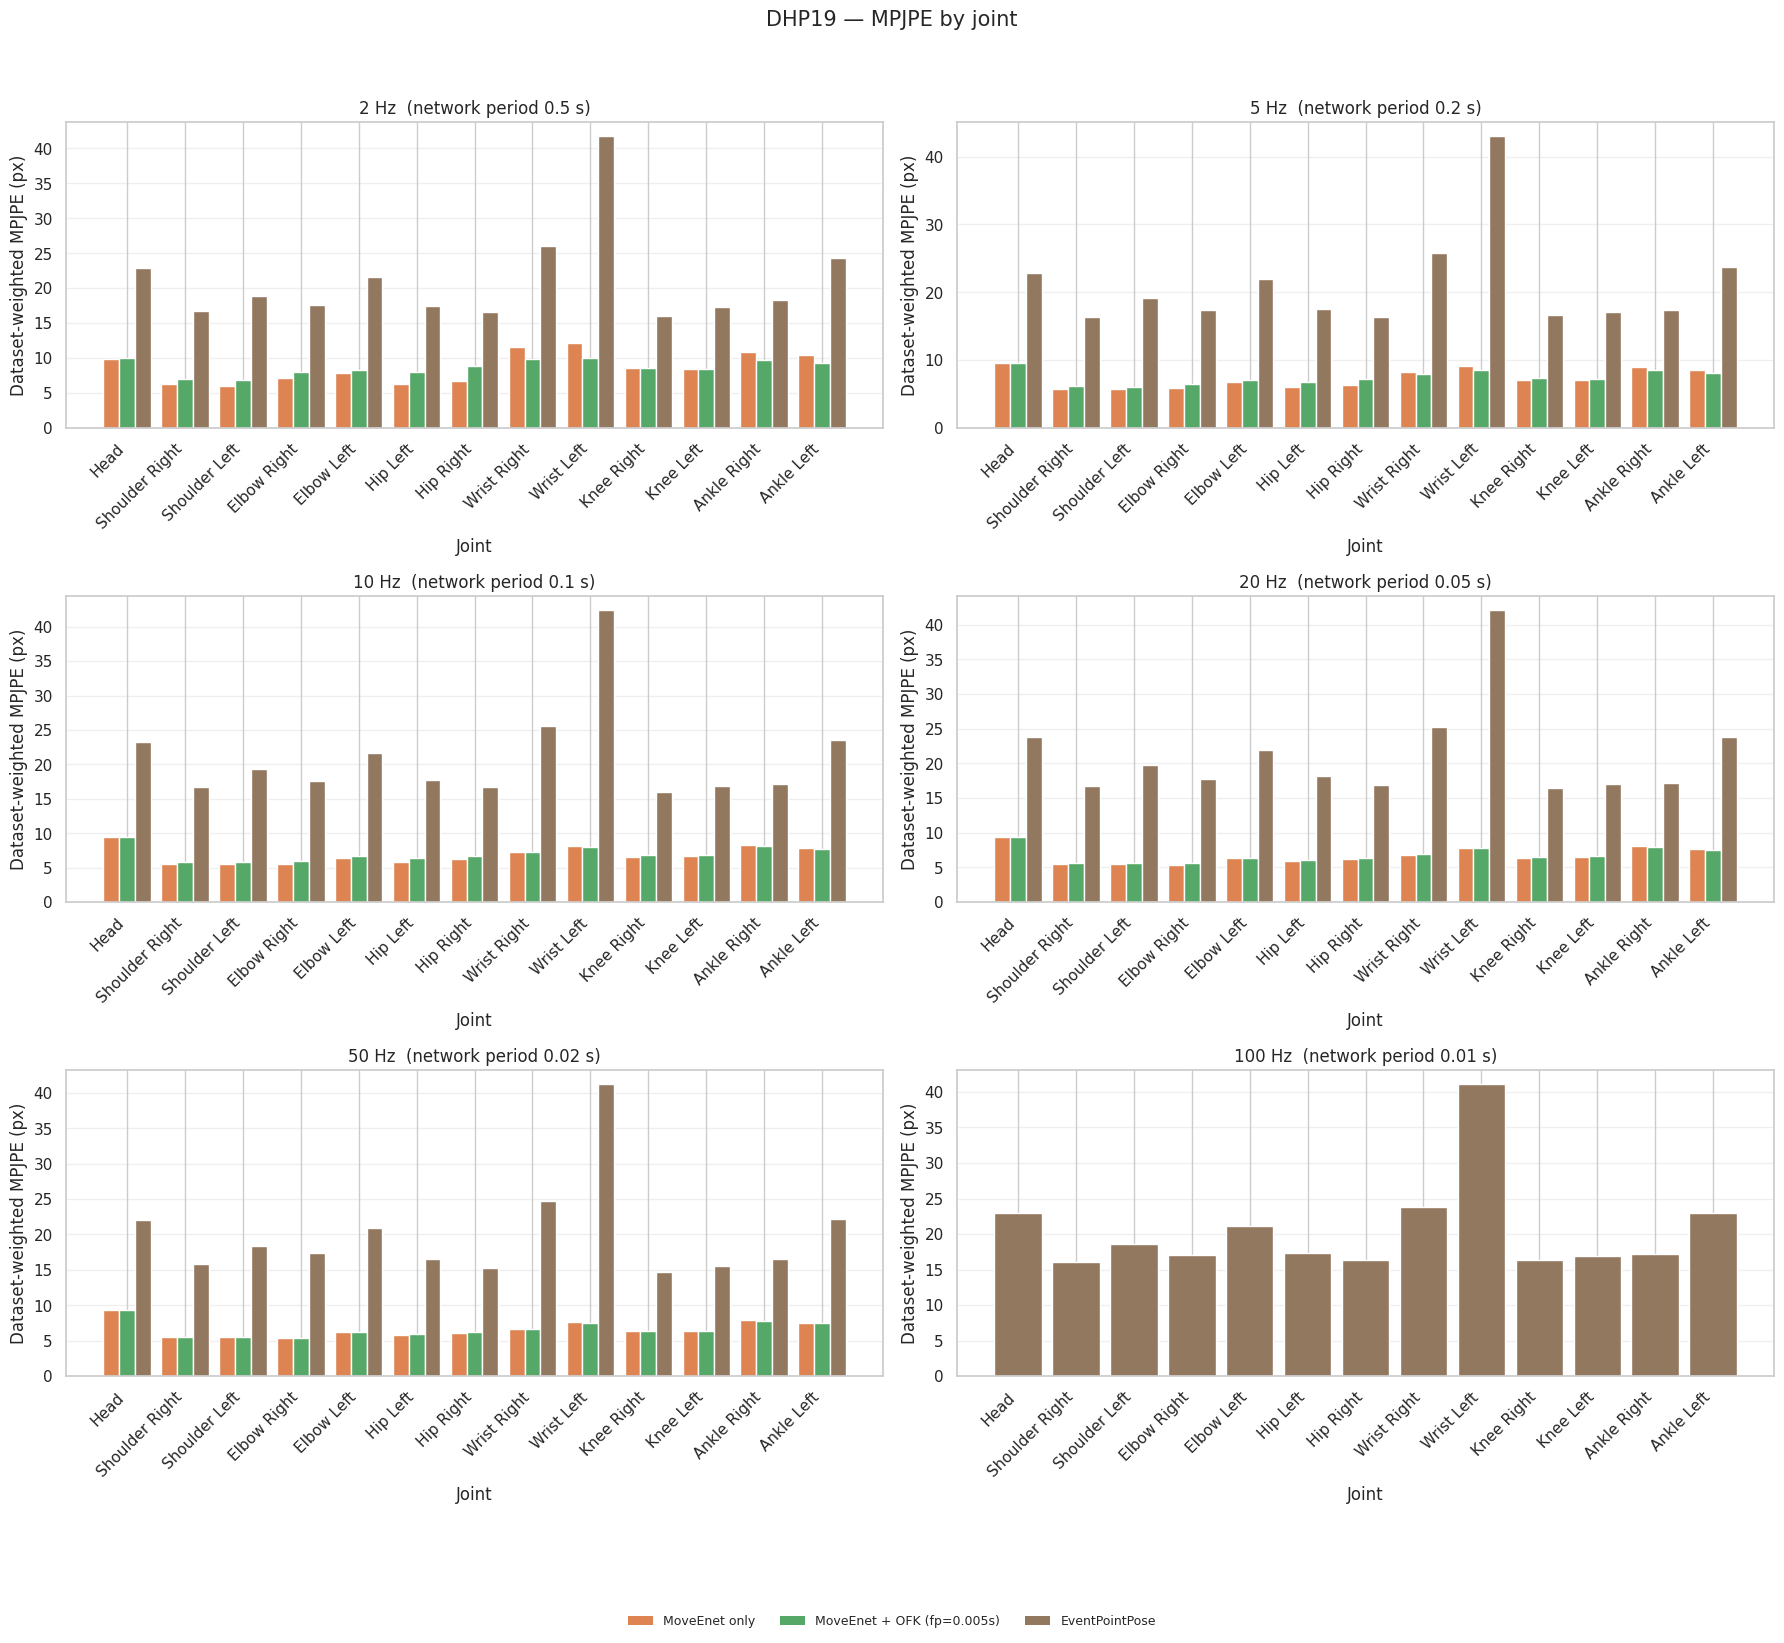

Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/plots/dhp19_joint_mpjpe_barplots_by_detection_rate.png


/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


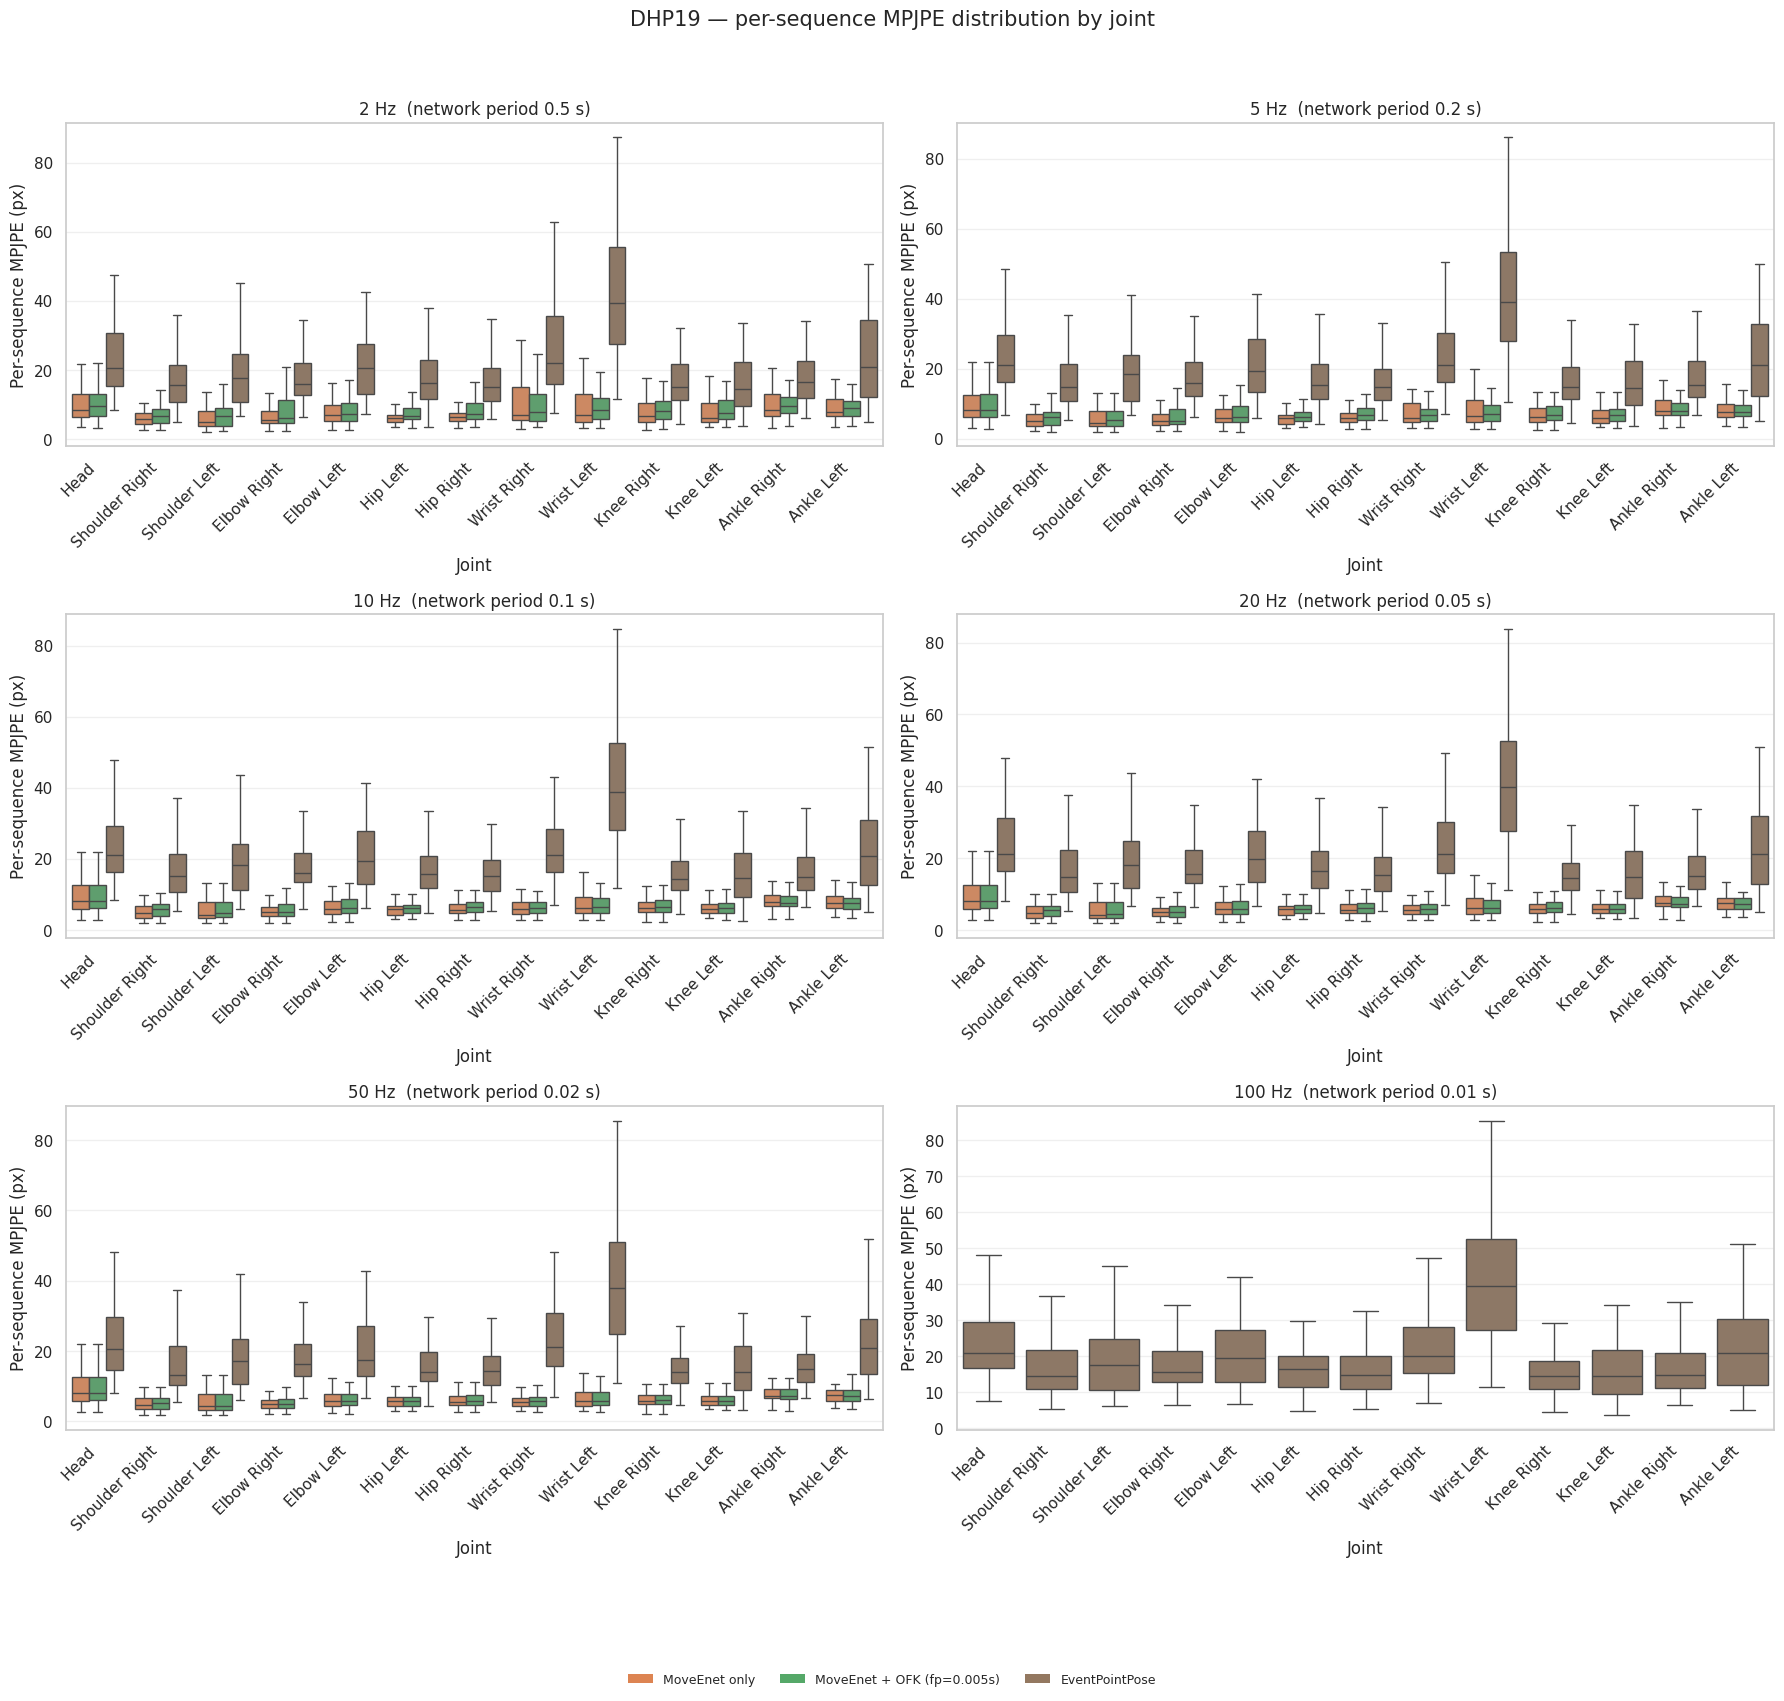

Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/plots/dhp19_joint_mpjpe_boxplots_by_detection_rate.png


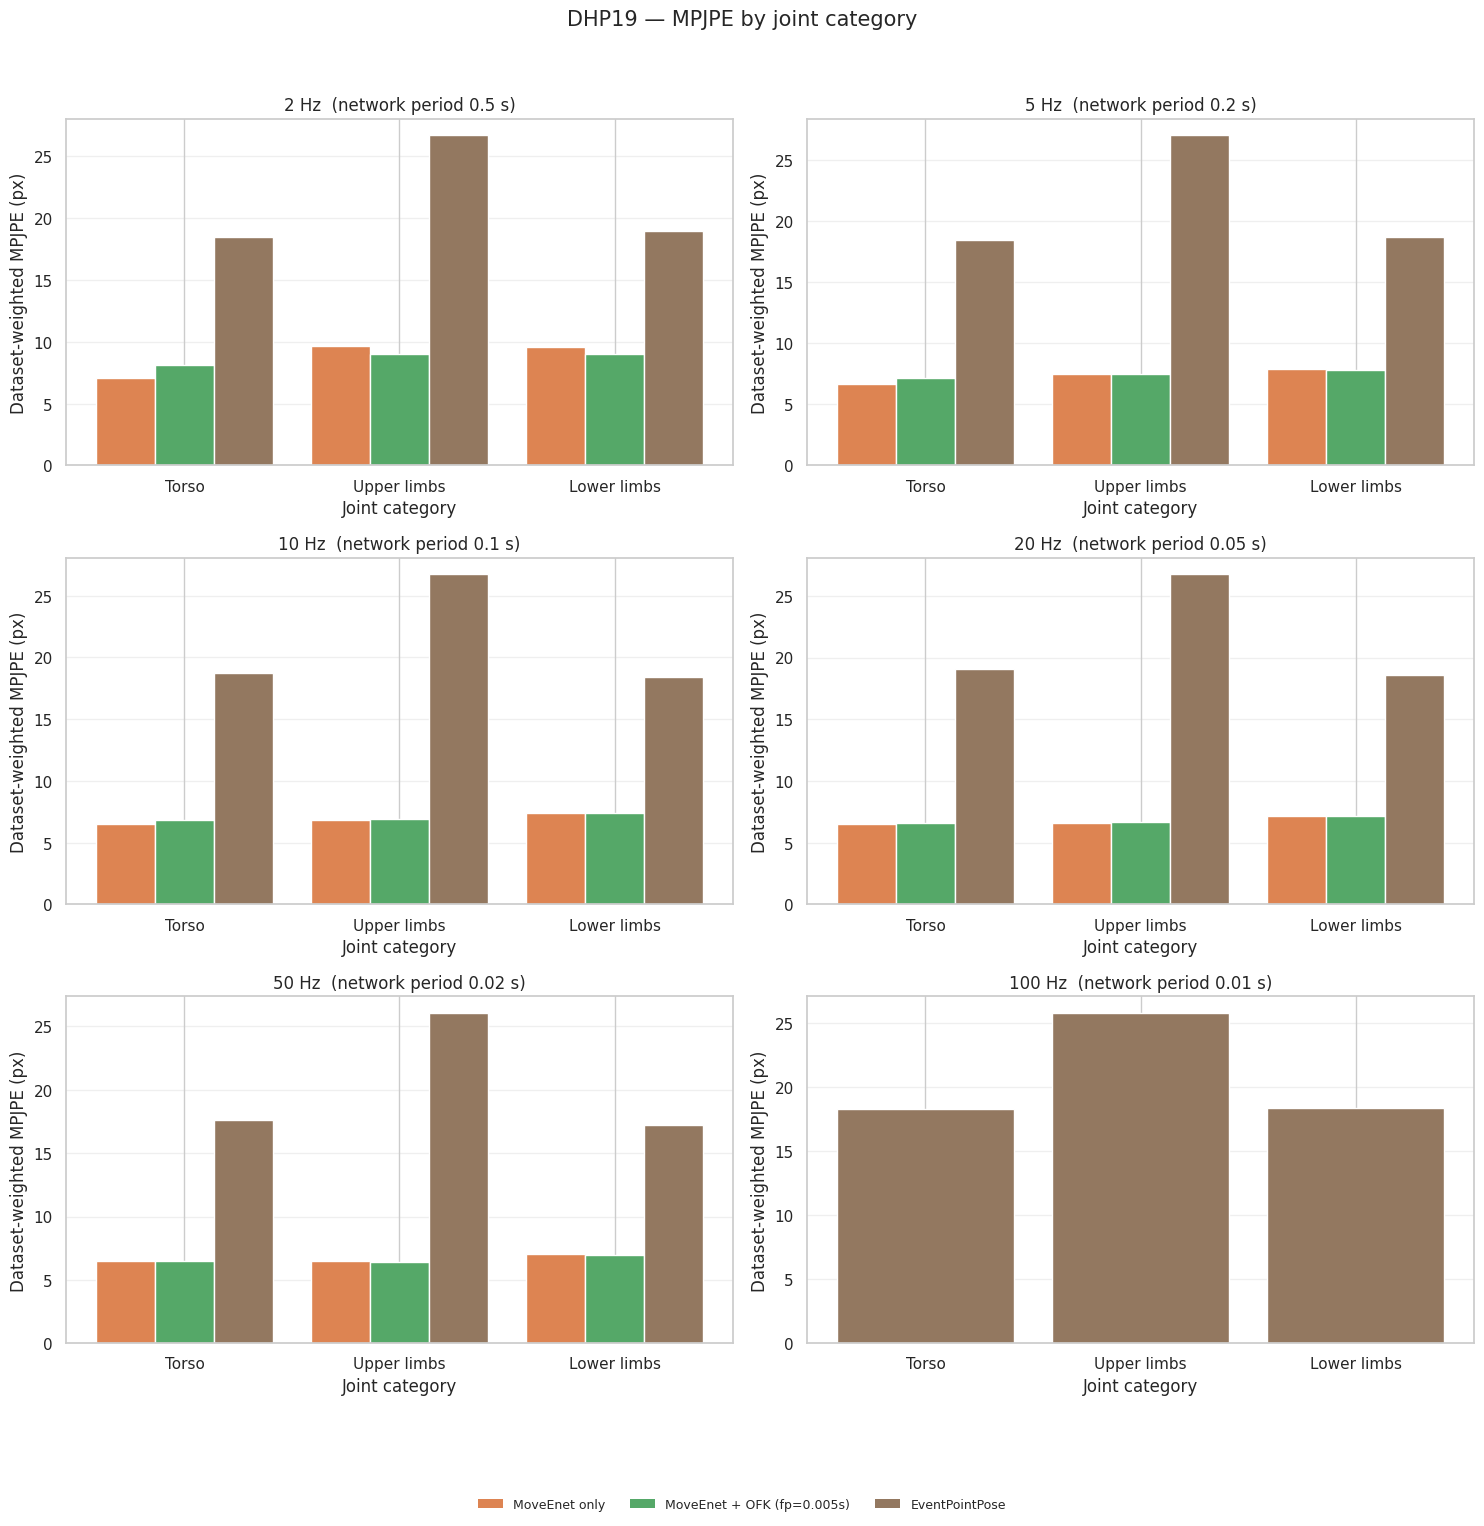

Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/plots/dhp19_joint_category_mpjpe_barplots_by_detection_rate.png
Creating plots for eH36M...


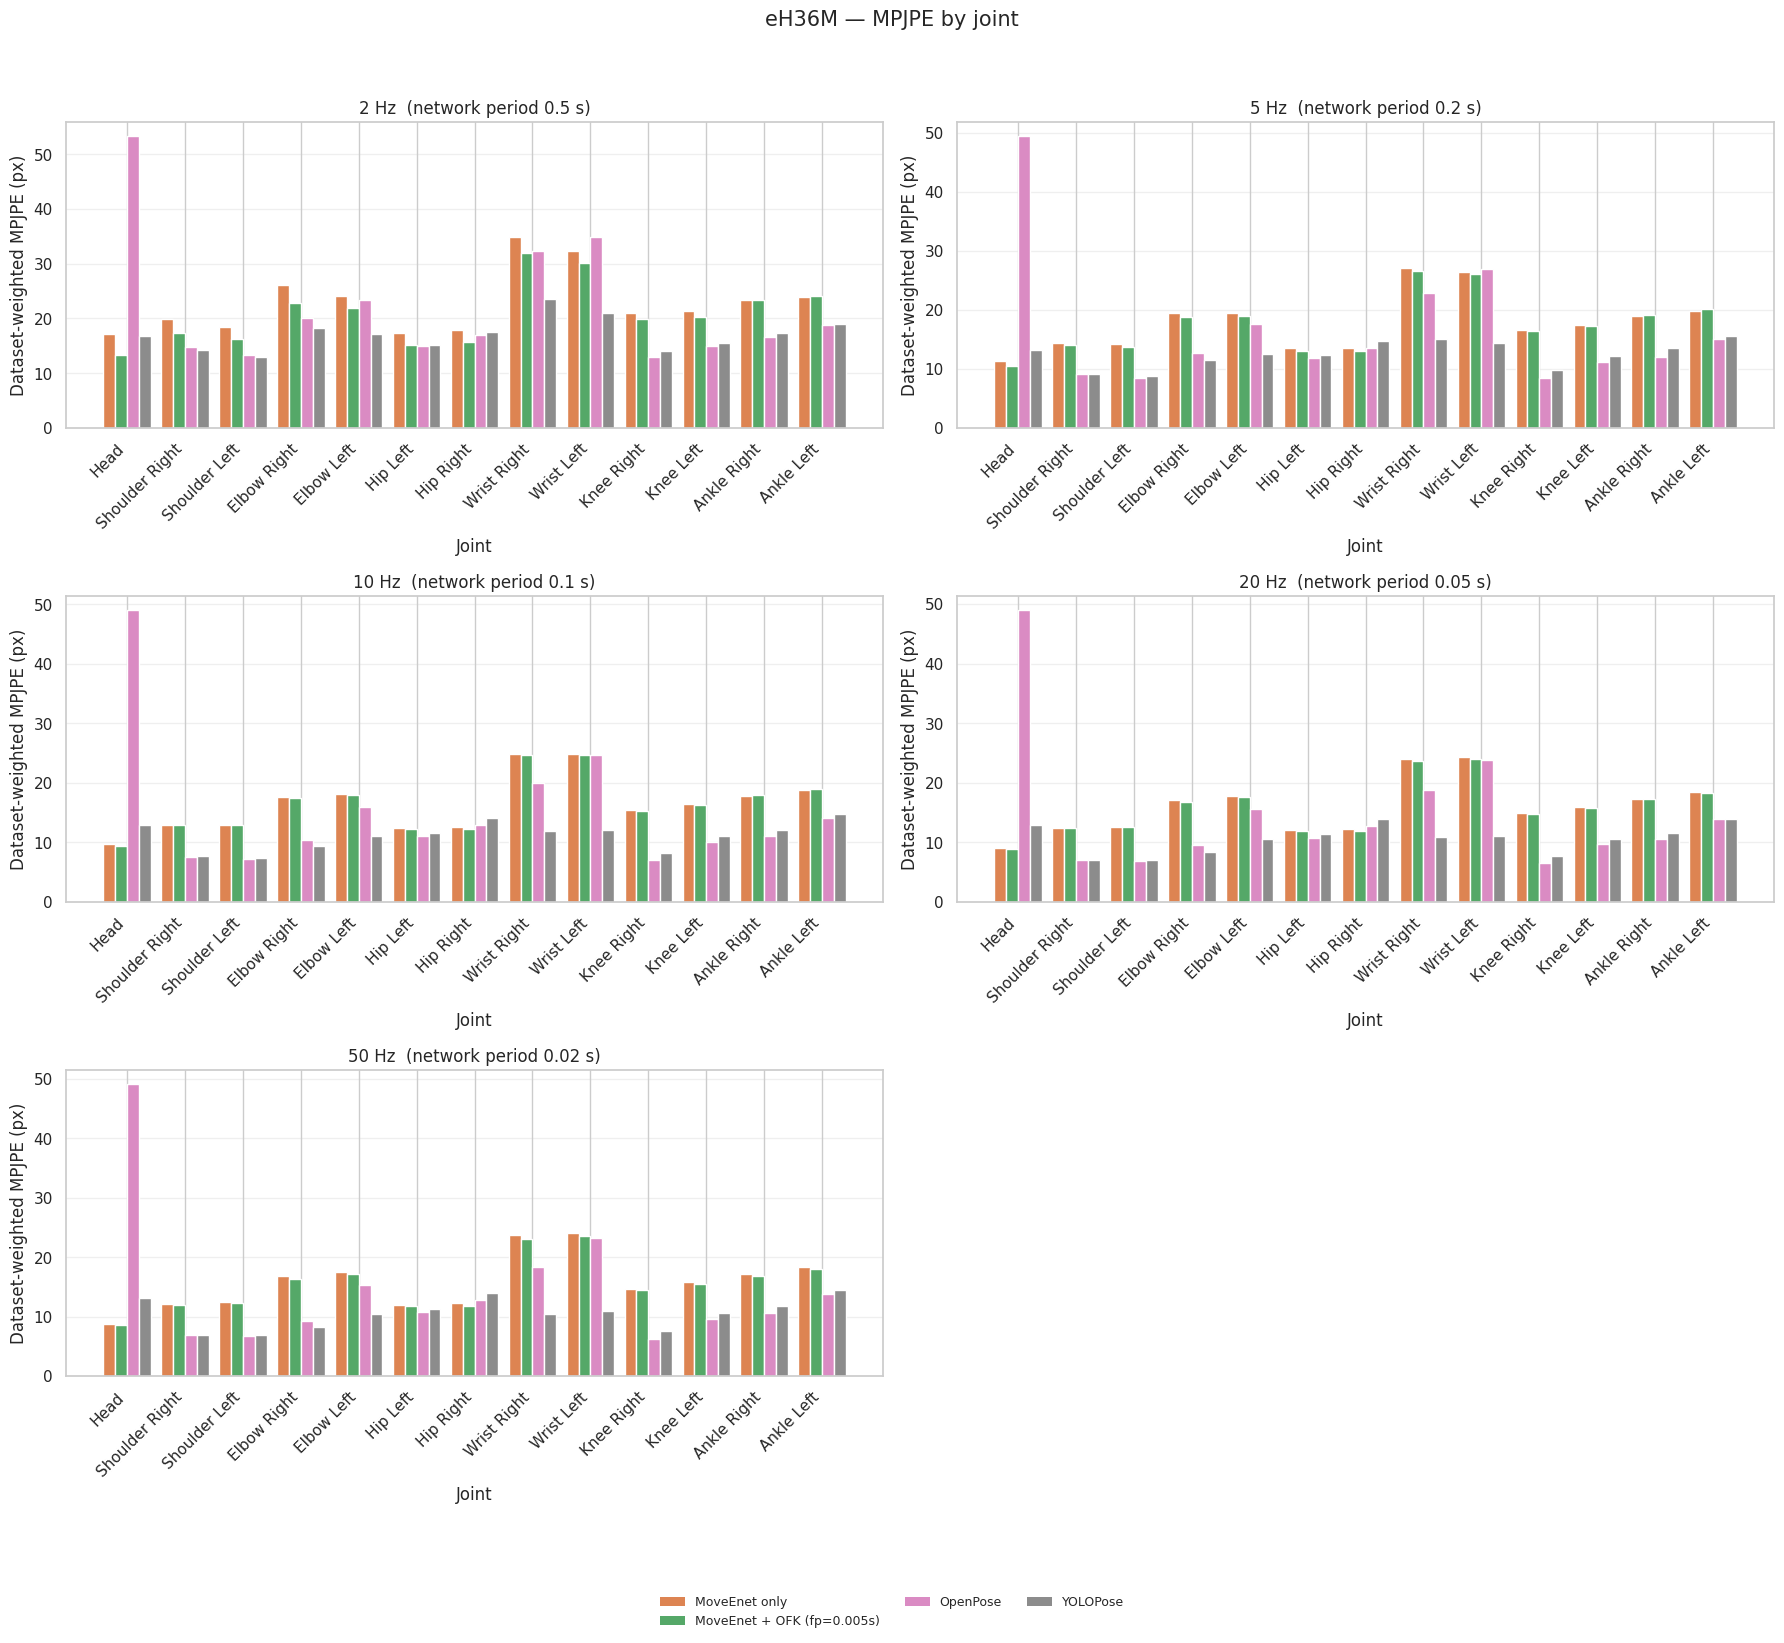

Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/plots/eh36m_joint_mpjpe_barplots_by_detection_rate.png


/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_39967/1210035554.py:205: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


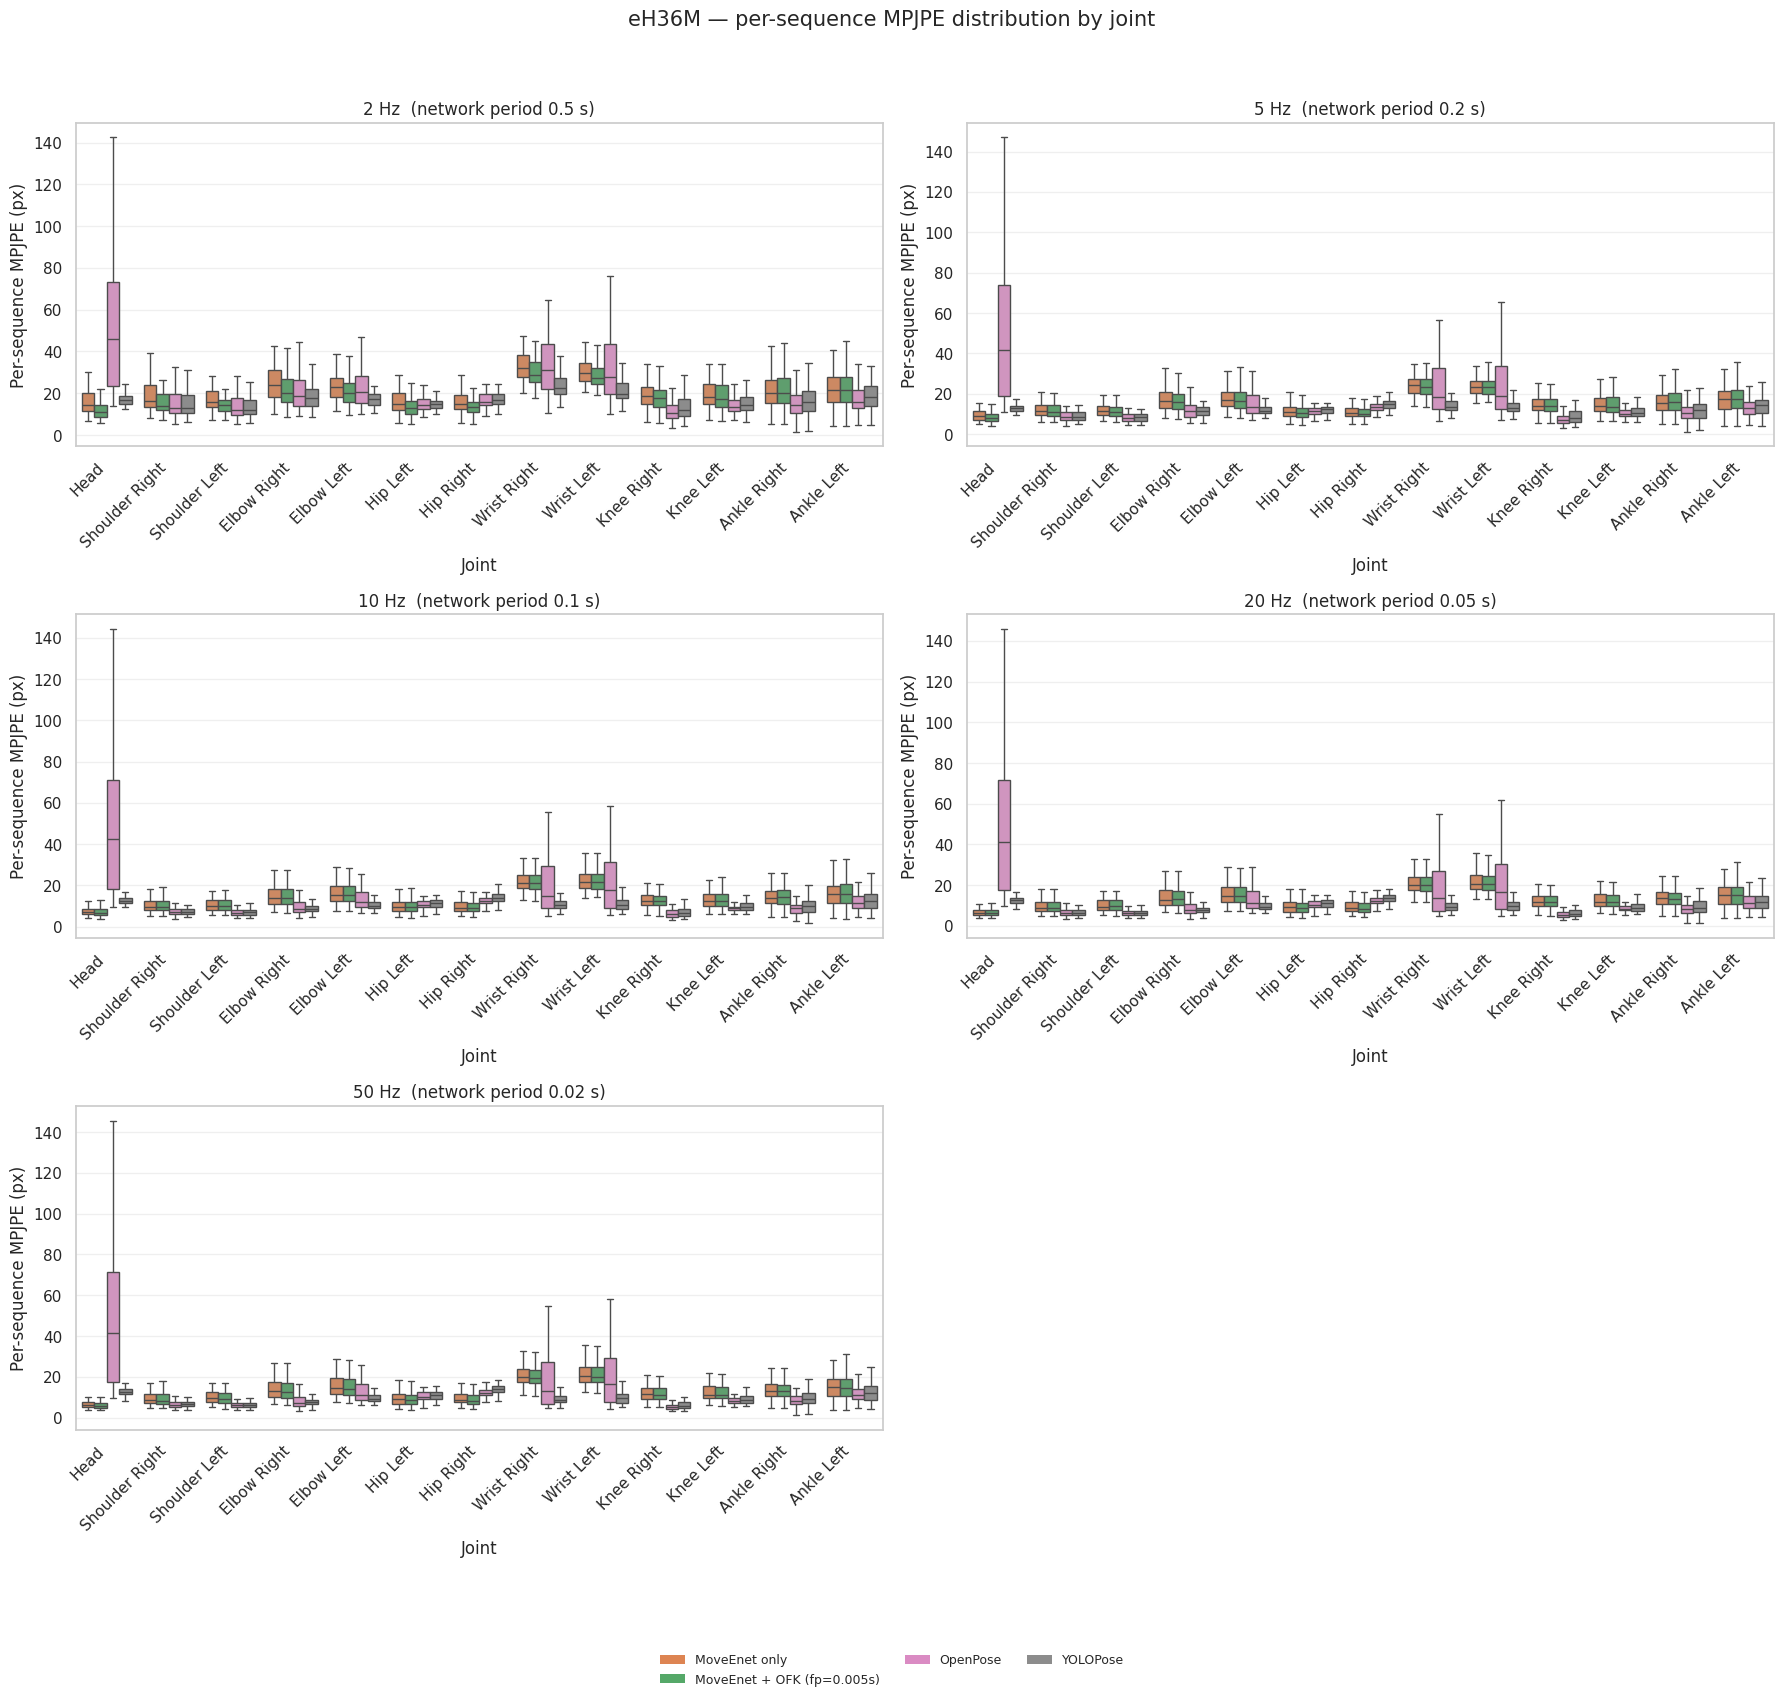

Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/plots/eh36m_joint_mpjpe_boxplots_by_detection_rate.png


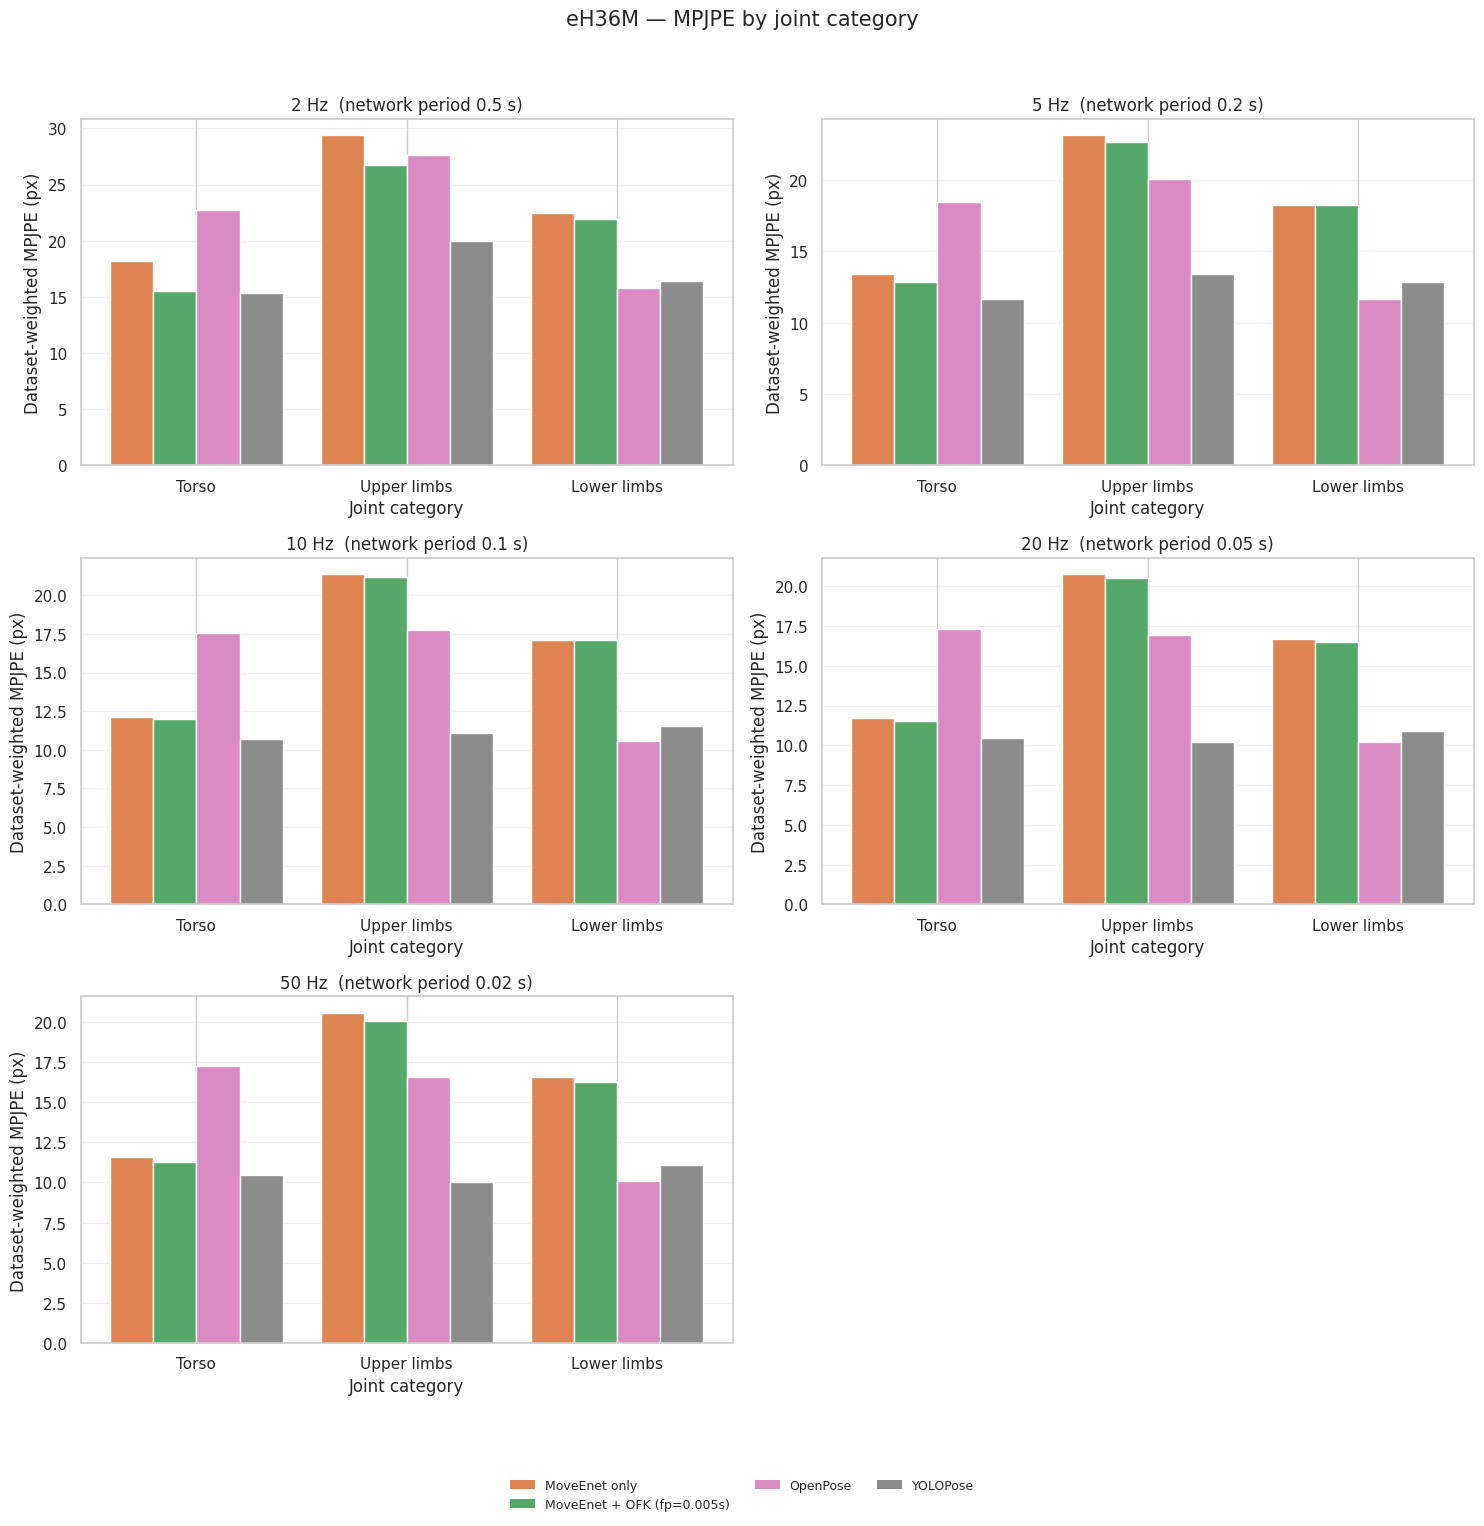

Saved: /data/MoveEnet_OFK_results/Comparison/selected_runs/joint-mpjpe__dhp19-eh36m__moveenet-only__moveenet-ofk__eventpointpose__openpose__yolopose/plots/eh36m_joint_category_mpjpe_barplots_by_detection_rate.png


In [17]:
for dataset in sorted(df_joint_table['dataset'].dropna().unique()):
    print(f'Creating plots for {DATASET_LABELS.get(dataset, dataset)}...')
    plot_joint_bar_panels(dataset)
    plot_joint_box_panels(dataset)
    plot_category_bar_panels(dataset)


## Compact result tables

In [18]:
joint_summary = df_joint_table[
    [
        'dataset',
        'detection_rate_hz',
        'method_variant',
        'joint_name',
        'joint_category',
        'mpjpe_px',
        'n_sequences',
        'n_points',
    ]
].copy()
joint_summary['mpjpe_px'] = joint_summary['mpjpe_px'].round(3)

category_summary = df_category_table[
    [
        'dataset',
        'detection_rate_hz',
        'method_variant',
        'joint_category',
        'mpjpe_px',
        'n_sequences',
        'n_points',
    ]
].copy()
category_summary['mpjpe_px'] = category_summary['mpjpe_px'].round(3)

print('Compact joint summary:')
display(joint_summary)

print('Compact category summary:')
display(category_summary)

for dataset in sorted(category_summary['dataset'].dropna().unique()):
    print(
        f'Category MPJPE table — '
        f'{DATASET_LABELS.get(dataset, dataset)}'
    )
    pivot = (
        category_summary[category_summary['dataset'] == dataset]
        .pivot_table(
            index=['detection_rate_hz', 'joint_category'],
            columns='method_variant',
            values='mpjpe_px',
            aggfunc='first',
        )
        .sort_index()
    )
    pivot.columns.name = None
    display(pivot)


Compact joint summary:


,dataset,detection_rate_hz,method_variant,joint_name,joint_category,mpjpe_px,n_sequences,n_points
0,dhp19,100.0,EventPointPose,head,Torso,22.927,79,355423
1,dhp19,100.0,EventPointPose,shoulder_right,Torso,16.064,79,355423
2,dhp19,100.0,EventPointPose,shoulder_left,Torso,18.599,79,355423
3,dhp19,100.0,EventPointPose,elbow_right,Upper limbs,17.073,79,355423
4,dhp19,100.0,EventPointPose,elbow_left,Upper limbs,21.172,79,355423
...,...,...,...,...,...,...,...,...
463,eh36m,2.0,YOLOPose,wrist_left,Upper limbs,20.967,70,164085
464,eh36m,2.0,YOLOPose,knee_right,Lower limbs,14.009,70,164085
465,eh36m,2.0,YOLOPose,knee_left,Lower limbs,15.458,70,164085
466,eh36m,2.0,YOLOPose,ankle_right,Lower limbs,17.413,70,164085


Compact category summary:


,dataset,detection_rate_hz,method_variant,joint_category,mpjpe_px,n_sequences,n_points
0,dhp19,100.0,EventPointPose,Lower limbs,18.345,79,1421692
1,dhp19,100.0,EventPointPose,Torso,18.247,79,1777115
2,dhp19,100.0,EventPointPose,Upper limbs,25.760,79,1421692
3,dhp19,50.0,EventPointPose,Lower limbs,17.221,69,1217684
4,dhp19,50.0,EventPointPose,Torso,17.607,69,1522105
...,...,...,...,...,...,...,...
103,eh36m,2.0,OpenPose,Torso,22.691,111,1275355
104,eh36m,2.0,OpenPose,Upper limbs,27.664,111,1020284
105,eh36m,2.0,YOLOPose,Lower limbs,16.451,70,656340
106,eh36m,2.0,YOLOPose,Torso,15.305,70,820425


Category MPJPE table — DHP19


EventPointPose  MoveEnet + OFK (fp=0.005s)  MoveEnet only
detection_rate_hz joint_category                                                           
2.0               Lower limbs             18.979                       9.019          9.602
                  Torso                   18.498                       8.138          7.031
                  Upper limbs             26.714                       9.014          9.653
5.0               Lower limbs             18.669                       7.812          7.924
                  Torso                   18.468                       7.177          6.644
                  Upper limbs             27.020                       7.483          7.508
10.0              Lower limbs             18.393                       7.372          7.372
                  Torso                   18.760                       6.823          6.528
                  Upper limbs             26.762                       6.941          6.832
20.0              Lower limbs             18.599                       7.149          7.147
                  Torso                   19.082                       6.627          6.479
                  Upper limbs             26.765                       6.636          6.568
50.0              Lower limbs             17.221                       7.001          7.050
                  Torso                   17.607                       6.494          6.458
                  Upper limbs             26.060                       6.431          6.472
100.0             Lower limbs             18.345                         NaN            NaN
                  Torso                   18.247                         NaN            NaN
                  Upper limbs             25.760                         NaN            NaN

Category MPJPE table — eH36M


MoveEnet + OFK (fp=0.005s)  MoveEnet only  OpenPose  YOLOPose
detection_rate_hz joint_category                                                               
2.0               Lower limbs                         21.911         22.440    15.802    16.451
                  Torso                               15.542         18.194    22.691    15.305
                  Upper limbs                         26.724         29.396    27.664    19.967
5.0               Lower limbs                         18.258         18.250    11.689    12.823
                  Torso                               12.877         13.421    18.493    11.668
                  Upper limbs                         22.651         23.149    20.052    13.392
10.0              Lower limbs                         17.094         17.104    10.589    11.559
                  Torso                               11.969         12.120    17.544    10.717
                  Upper limbs                         21.209         21.374    17.764    11.106
20.0              Lower limbs                         16.523         16.670    10.211    10.910
                  Torso                               11.535         11.692    17.290    10.438
                  Upper limbs                         20.506         20.766    16.940    10.232
50.0              Lower limbs                         16.225         16.531    10.066    11.092
                  Torso                               11.278         11.563    17.241    10.449
                  Upper limbs                         20.063         20.538    16.554    10.004